In [1]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

PROJECT_PATH = "/content/drive/MyDrive/VCR-Model"

os.makedirs(PROJECT_PATH, exist_ok=True)
os.chdir(PROJECT_PATH)

print("Working directory:", os.getcwd())

Working directory: /content/drive/MyDrive/VCR-Model


In [3]:
%pip install -q -U "numpy==2.0.2" "pandas==2.2.2" datasets transformers accelerate bitsandbytes qwen-vl-utils sentencepiece opencv-python-headless scikit-learn matplotlib gradio pyyaml tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 8.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 134.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 142.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 137.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.7/30.7 MB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 32.5 MB/s eta 0:00:00


In [3]:
import torch
import datasets
import transformers
import pandas as pd
import numpy as np
import cv2
import gradio as gr

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Setup complete")

Pandas: 2.2.2
NumPy: 2.0.2
PyTorch: 2.11.0+cu128
Transformers: 5.15.0
Datasets: 5.0.1
CUDA available: True
GPU: Tesla T4
Setup complete


In [4]:
from datasets import load_dataset

vcr_stream = load_dataset(
    "Rowan/vcr",
    "questions",
    split="validation",
    streaming=True
)

first_sample = next(iter(vcr_stream))

print("Dataset connected successfully!")
print("\nAvailable fields:")
print(list(first_sample.keys()))

README.md:   0%|          | 0.00/1.80k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/59 [00:00<?, ?it/s]

Dataset connected successfully!

Available fields:
['movie', 'objects', 'interesting_scores', 'answer_likelihood', 'img_fn', 'metadata_fn', 'answer_orig', 'question_orig', 'rationale_orig', 'question_tokens', 'answer_choice_tokens', 'answer_label', 'answer_match_iter', 'answer_sources', 'rationale_choice_tokens', 'rationale_sources', 'rationale_match_iter', 'rationale_label', 'source_zip_crc_mismatch', 'img_id', 'question_number', 'annot_id', 'match_fold', 'match_index', 'question_text', 'answer_choice_texts', 'rationale_choice_texts']


In [5]:
print("Total fields:", len(first_sample))
print("\nFIELD NAME | TYPE | PREVIEW")
print("-" * 90)

for key, value in first_sample.items():
    preview = str(value).replace("\n", " ")

    if len(preview) > 250:
        preview = preview[:250] + "..."

    print(f"\n{key}")
    print("Type:", type(value).__name__)
    print("Value:", preview)

Total fields: 27

FIELD NAME | TYPE | PREVIEW
------------------------------------------------------------------------------------------

movie
Type: str
Value: 1054_Harry_Potter_and_the_prisoner_of_azkaban

objects
Type: list
Value: ['person', 'person', 'person', 'car', 'cellphone', 'clock']

interesting_scores
Type: list
Value: [-1, 0]

answer_likelihood
Type: str
Value: likely

img_fn
Type: str
Value: lsmdc_1054_Harry_Potter_and_the_prisoner_of_azkaban/1054_Harry_Potter_and_the_prisoner_of_azkaban_00.01.46.736-00.01.50.168@0.jpg

metadata_fn
Type: str
Value: lsmdc_1054_Harry_Potter_and_the_prisoner_of_azkaban/1054_Harry_Potter_and_the_prisoner_of_azkaban_00.01.46.736-00.01.50.168@0.json

answer_orig
Type: str
Value: 1 is upset and disgusted.

question_orig
Type: str
Value: How is 1 feeling?

rationale_orig
Type: str
Value: 1's expression is twisted in digust.

question_tokens
Type: list
Value: [{'kind': 'text', 'text': 'How', 'object_indices': []}, {'kind': 'text', 'text': 'is', 'ob

In [6]:
samples = list(vcr_stream.take(8))

for sample_number, sample in enumerate(samples, start=1):
    print("\n" + "=" * 100)
    print(f"SAMPLE {sample_number}")
    print("=" * 100)

    print("Annotation ID:", sample["annot_id"])
    print("Image path:", sample["img_fn"])
    print("Objects:", sample["objects"])
    print("\nQuestion:", sample["question_text"])

    print("\nFour answer candidates:")
    for index, answer in enumerate(sample["answer_choice_texts"]):
        marker = "  <-- CORRECT" if index == sample["answer_label"] else ""
        print(f"  A{index}: {answer}{marker}")

    print("\nFour rationale candidates:")
    for index, rationale in enumerate(sample["rationale_choice_texts"]):
        marker = "  <-- CORRECT" if index == sample["rationale_label"] else ""
        print(f"  R{index}: {rationale}{marker}")

    print(
        f"\nCorrect pair: "
        f"A{sample['answer_label']} + R{sample['rationale_label']}"
    )


SAMPLE 1
Annotation ID: val-0
Image path: lsmdc_1054_Harry_Potter_and_the_prisoner_of_azkaban/1054_Harry_Potter_and_the_prisoner_of_azkaban_00.01.46.736-00.01.50.168@0.jpg
Objects: ['person', 'person', 'person', 'car', 'cellphone', 'clock']

Question: How is [person0] feeling?

Four answer candidates:
  A0: [person0] is feeling amused.
  A1: [person0] is upset and disgusted.  <-- CORRECT
  A2: [person0] is feeling very scared.
  A3: [person0] is feeling uncomfortable with [person2].

Four rationale candidates:
  R0: [person0]' s mouth has wide eyes and an open mouth.
  R1: When people have their mouth back like that and their eyebrows lowered they are usually disgusted by what they see.
  R2: [person2,person1,person0] are seated at a dining table where food would be served to them. people unaccustomed to odd or foreign dishes may make disgusted looks at the thought of eating it.
  R3: [person0]' s expression is twisted in disgust.  <-- CORRECT

Correct pair: A1 + R3

SAMPLE 2
Annotati

In [7]:
from datasets import load_dataset

unique_image_paths = list(
    dict.fromkeys(sample["img_fn"] for sample in samples)
)

print("Unique images required:", len(unique_image_paths))

image_stream = load_dataset(
    "Rowan/vcr",
    "image_examples",
    split="validation",
    streaming=True
)

image_rows = {}

for row in image_stream:
    if row["img_fn"] in unique_image_paths:
        image_rows[row["img_fn"]] = row
        print("Found:", row["img_fn"])

    if len(image_rows) == len(unique_image_paths):
        break

print(
    f"\nImages found: {len(image_rows)}/{len(unique_image_paths)}"
)

Unique images required: 3


Resolving data files:   0%|          | 0/59 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/59 [00:00<?, ?it/s]

Found: lsmdc_1054_Harry_Potter_and_the_prisoner_of_azkaban/1054_Harry_Potter_and_the_prisoner_of_azkaban_00.01.46.736-00.01.50.168@0.jpg
Found: lsmdc_0014_Ist_das_Leben_nicht_schoen/0014_Ist_das_Leben_nicht_schoen_01.14.39.611-01.14.40.870@0.jpg
Found: lsmdc_1054_Harry_Potter_and_the_prisoner_of_azkaban/1054_Harry_Potter_and_the_prisoner_of_azkaban_01.20.34.896-01.20.49.435@3.jpg

Images found: 3/3


In [8]:
from datasets import load_dataset

# 8 samples se repeated image paths hata kar unique paths rakhna
unique_image_paths = list(
    dict.fromkeys(sample["img_fn"] for sample in samples)
)

print("Total question samples:", len(samples))
print("Unique images required:", len(unique_image_paths))

# Actual images ko streaming mode mein access karna
image_stream = load_dataset(
    "Rowan/vcr",
    "image_examples",
    split="validation",
    streaming=True
)

# Har unique image ko sirf ek baar store karna
image_rows = {}

for row in image_stream:
    image_path = row["img_fn"]

    if image_path in unique_image_paths:
        image_rows[image_path] = row
        print("Found:", image_path)

    if len(image_rows) == len(unique_image_paths):
        break

print("\nTotal questions:", len(samples))
print("Images loaded only once:", len(image_rows))
print(f"Images found: {len(image_rows)}/{len(unique_image_paths)}")

Total question samples: 8
Unique images required: 3


Resolving data files:   0%|          | 0/59 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/59 [00:00<?, ?it/s]

'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/Rowan/vcr/resolve/76c63a5cf6a4dcbaf7215628fe0accbb5d7156fc/image_examples/validation-00000-of-00008.parquet
Retrying in 1s [Retry 1/5].


Found: lsmdc_1054_Harry_Potter_and_the_prisoner_of_azkaban/1054_Harry_Potter_and_the_prisoner_of_azkaban_00.01.46.736-00.01.50.168@0.jpg
Found: lsmdc_0014_Ist_das_Leben_nicht_schoen/0014_Ist_das_Leben_nicht_schoen_01.14.39.611-01.14.40.870@0.jpg
Found: lsmdc_1054_Harry_Potter_and_the_prisoner_of_azkaban/1054_Harry_Potter_and_the_prisoner_of_azkaban_01.20.34.896-01.20.49.435@3.jpg

Total questions: 8
Images loaded only once: 3
Images found: 3/3


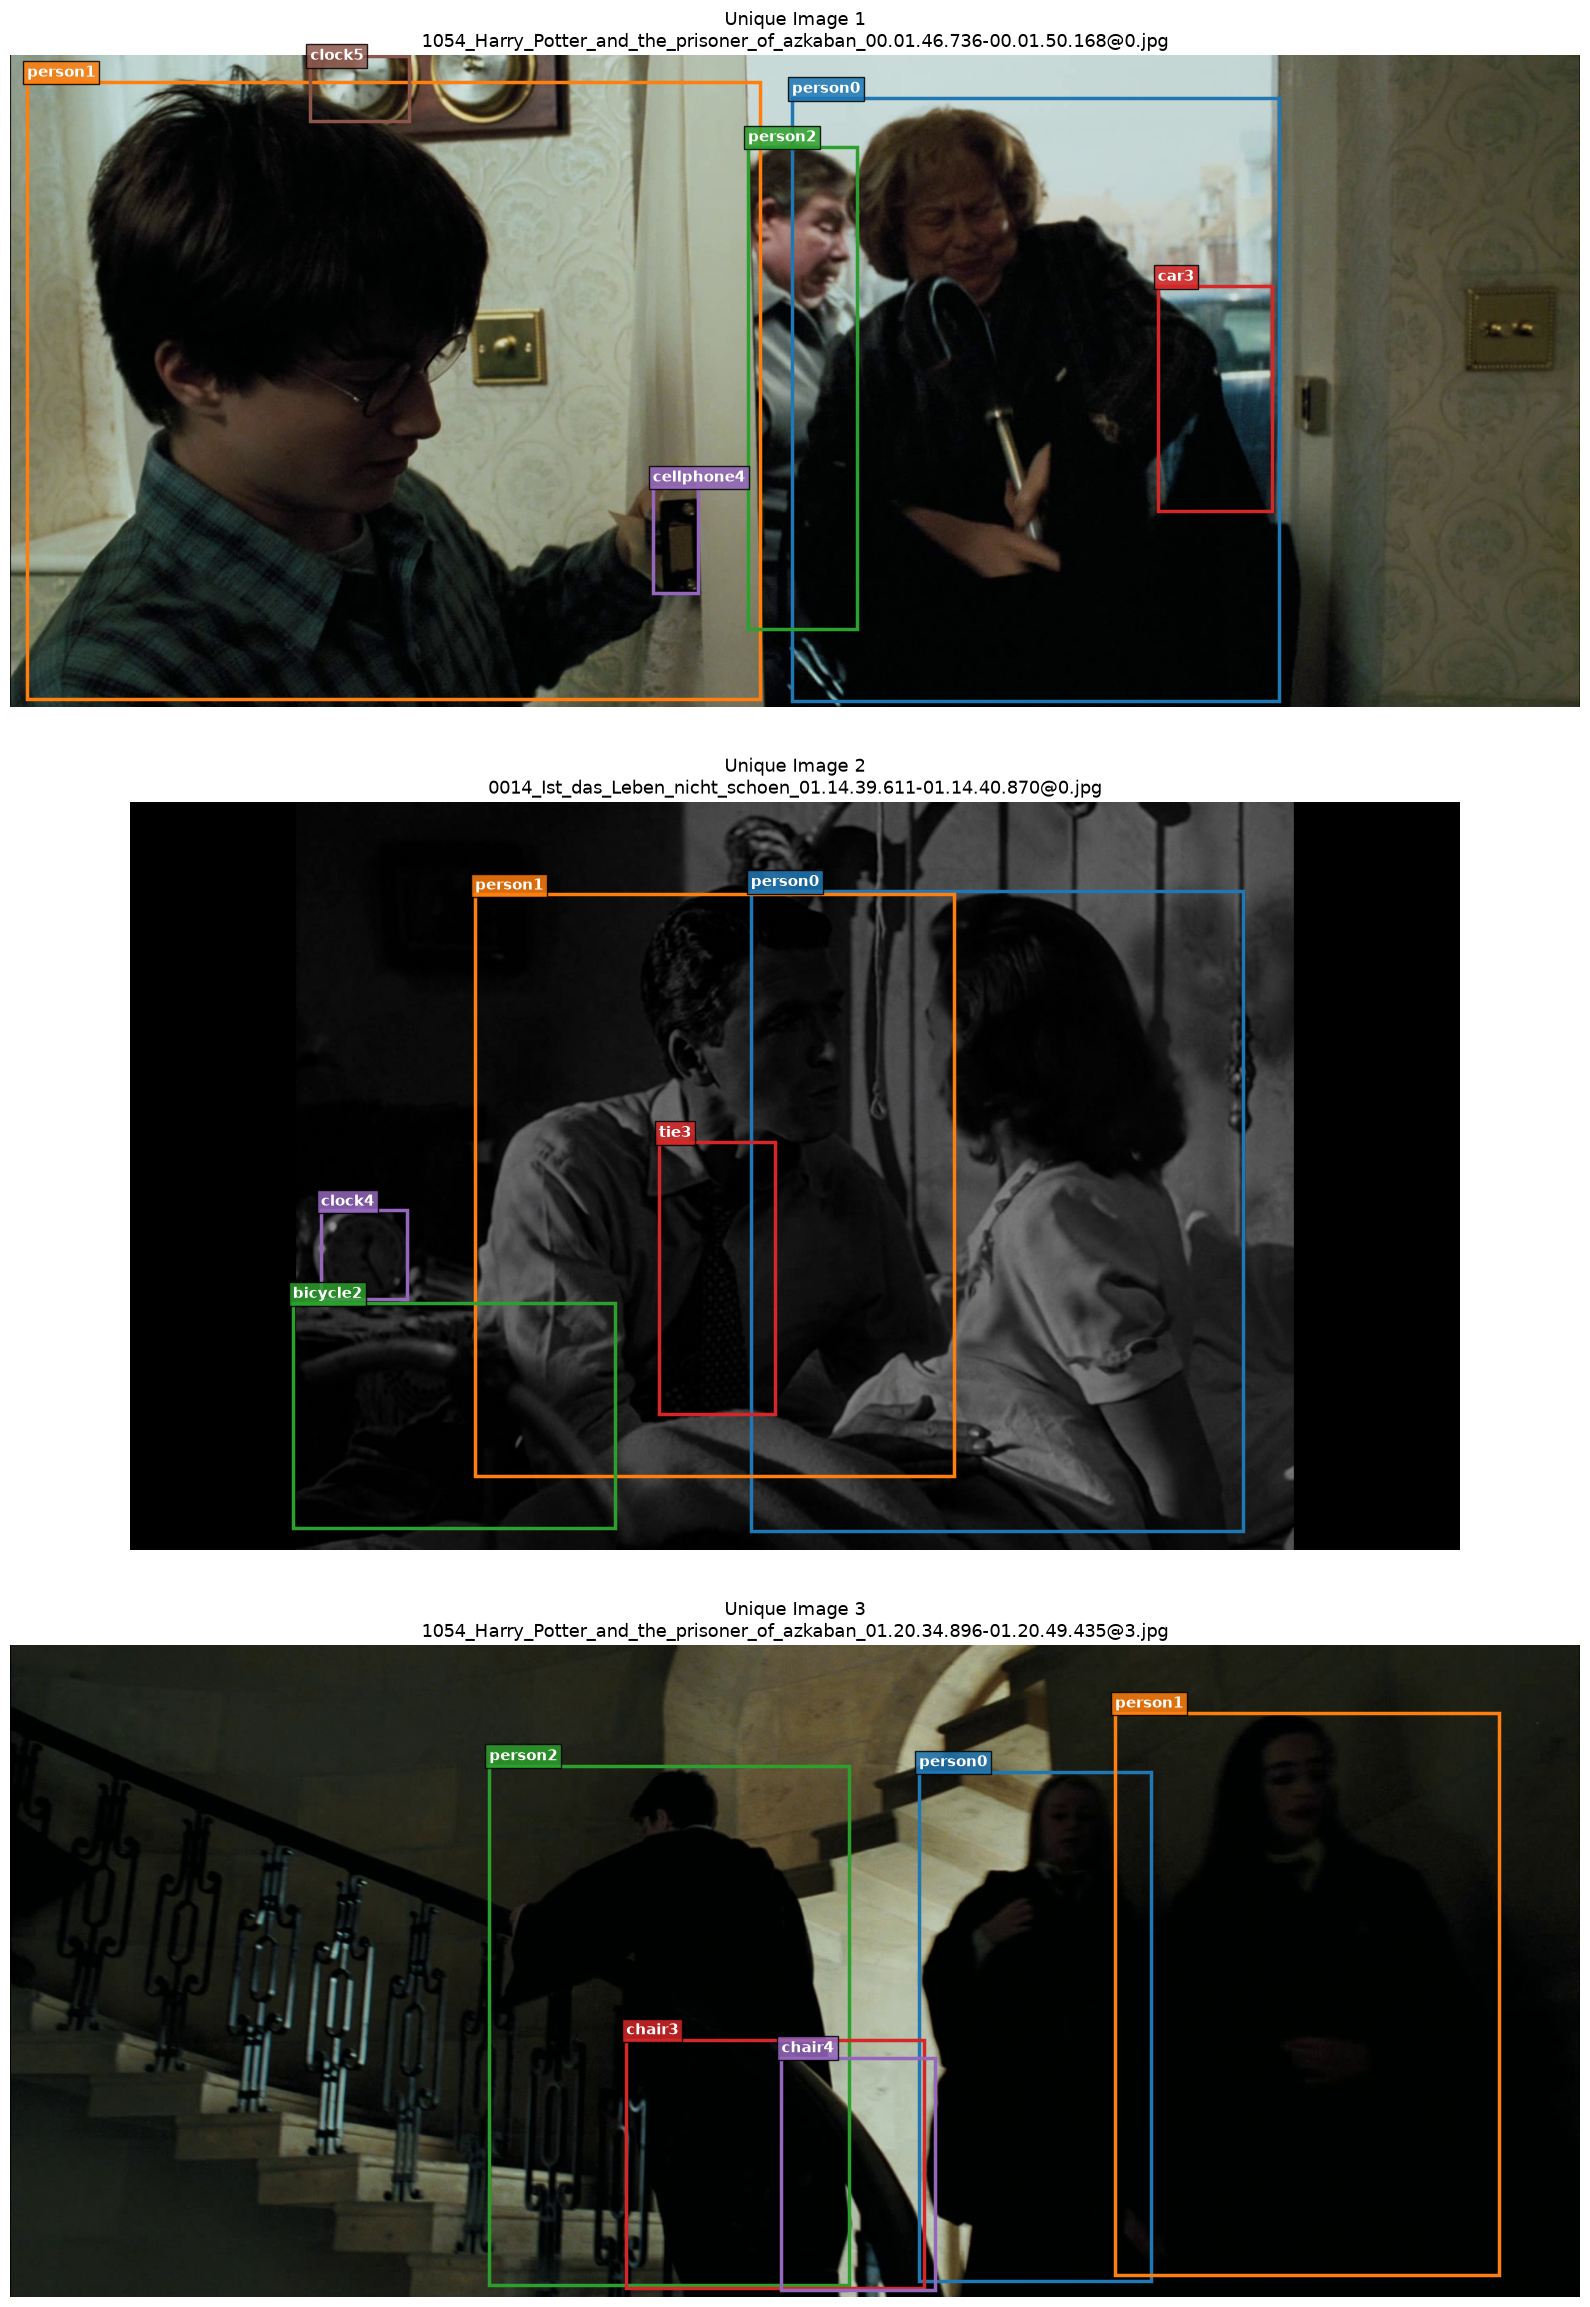

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

colours = plt.cm.tab10(np.linspace(0, 1, 10))

fig, axes = plt.subplots(
    len(unique_image_paths),
    1,
    figsize=(16, 8 * len(unique_image_paths))
)

if len(unique_image_paths) == 1:
    axes = [axes]

for image_number, image_path in enumerate(unique_image_paths):
    row = image_rows[image_path]
    image = row["image"]
    objects = row["objects"]
    boxes = row["boxes"]

    axis = axes[image_number]
    axis.imshow(image)

    for object_index, (object_name, box) in enumerate(
        zip(objects, boxes)
    ):
        x1, y1, x2, y2 = box[:4]
        colour = colours[object_index % len(colours)]
        label = f"{object_name}{object_index}"

        rectangle = Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2.5,
            edgecolor=colour,
            facecolor="none"
        )

        axis.add_patch(rectangle)

        axis.text(
            x1,
            max(5, y1 - 7),
            label,
            color="white",
            fontsize=11,
            fontweight="bold",
            bbox={
                "facecolor": colour,
                "alpha": 0.85,
                "pad": 3
            }
        )

    axis.set_title(
        f"Unique Image {image_number + 1}\n"
        f"{os.path.basename(image_path)}",
        fontsize=13
    )
    axis.axis("off")

plt.tight_layout()
plt.show()

In [10]:
from PIL import ImageDraw, ImageFont
import matplotlib.pyplot as plt

GROUNDING_COLOURS = [
    "#00A6FF",
    "#FF8C00",
    "#22C55E",
    "#EF4444",
    "#A855F7",
    "#EAB308",
    "#EC4899",
    "#14B8A6"
]

def get_label_font(image_width):
    font_size = max(18, image_width // 65)

    try:
        return ImageFont.truetype(
            "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
            font_size
        )
    except OSError:
        return ImageFont.load_default()


def create_grounded_view(image_row):
    grounded_image = image_row["image"].convert("RGB").copy()
    draw = ImageDraw.Draw(grounded_image)

    font = get_label_font(grounded_image.width)
    line_width = max(3, grounded_image.width // 400)

    for object_index, (object_name, box) in enumerate(
        zip(image_row["objects"], image_row["boxes"])
    ):
        x1, y1, x2, y2 = map(int, box[:4])
        colour = GROUNDING_COLOURS[
            object_index % len(GROUNDING_COLOURS)
        ]

        label = f"{object_name}{object_index}"

        draw.rectangle(
            [x1, y1, x2, y2],
            outline=colour,
            width=line_width
        )

        text_box = draw.textbbox(
            (x1, y1),
            label,
            font=font
        )

        text_width = text_box[2] - text_box[0]
        text_height = text_box[3] - text_box[1]
        label_y = max(0, y1 - text_height - 8)

        draw.rectangle(
            [
                x1,
                label_y,
                x1 + text_width + 10,
                label_y + text_height + 8
            ],
            fill=colour
        )

        draw.text(
            (x1 + 5, label_y + 2),
            label,
            fill="white",
            font=font
        )

    return grounded_image


dual_views = {}

for image_path, image_row in image_rows.items():
    dual_views[image_path] = {
        "original": image_row["image"].convert("RGB"),
        "grounded": create_grounded_view(image_row)
    }

print("Dual views prepared:", len(dual_views))

Dual views prepared: 3


In [12]:
grouped_records = {}

for sample in samples:
    image_path = sample["img_fn"]

    if image_path not in grouped_records:
        grouped_records[image_path] = {
            "image_path": image_path,
            "original_image": dual_views[image_path]["original"],
            "grounded_image": dual_views[image_path]["grounded"],
            "objects": sample["objects"],
            "questions": []
        }

    question_record = {
        "annot_id": sample["annot_id"],
        "question": sample["question_text"],
        "answer_choices": sample["answer_choice_texts"],
        "rationale_choices": sample["rationale_choice_texts"],
        "answer_label": sample["answer_label"],
        "rationale_label": sample["rationale_label"]
    }

    grouped_records[image_path]["questions"].append(
        question_record
    )


print("Unique image records:", len(grouped_records))

total_grouped_questions = 0

for image_number, record in enumerate(
    grouped_records.values(),
    start=1
):
    question_count = len(record["questions"])
    total_grouped_questions += question_count

    print(
        f"Image {image_number}: "
        f"{question_count} linked questions"
    )

print("Total linked questions:", total_grouped_questions)

Unique image records: 3
Image 1: 3 linked questions
Image 2: 2 linked questions
Image 3: 3 linked questions
Total linked questions: 8


In [13]:
import re

def normalize_vcr_text(text):
    text = str(text)

    # Fix contractions and possessives:
    # doesn' t -> doesn't, person0]' s -> person0]'s
    text = re.sub(
        r"'\s+(s|t|re|ve|ll|d|m)\b",
        r"'\1",
        text,
        flags=re.IGNORECASE
    )

    # Remove spaces before punctuation
    text = re.sub(r"\s+([.,!?;:])", r"\1", text)

    # Replace repeated spaces with one space
    text = re.sub(r"\s+", " ", text).strip()

    return text


for image_record in grouped_records.values():
    for question_record in image_record["questions"]:
        question_record["clean_question"] = normalize_vcr_text(
            question_record["question"]
        )

        question_record["clean_answer_choices"] = [
            normalize_vcr_text(answer)
            for answer in question_record["answer_choices"]
        ]

        question_record["clean_rationale_choices"] = [
            normalize_vcr_text(rationale)
            for rationale in question_record["rationale_choices"]
        ]


example = grouped_records[unique_image_paths[0]]["questions"][0]

print("Original question:")
print(example["question"])

print("\nClean question:")
print(example["clean_question"])

print("\nOriginal rationale:")
print(example["rationale_choices"][3])

print("\nClean rationale:")
print(example["clean_rationale_choices"][3])

Original question:
How is [person0] feeling?

Clean question:
How is [person0] feeling?

Original rationale:
[person0]' s expression is twisted in disgust.

Clean rationale:
[person0]'s expression is twisted in disgust.


In [14]:
answer_candidate_records = []
pair_candidate_records = []
evaluation_labels = {}

for image_path, image_record in grouped_records.items():
    for question_record in image_record["questions"]:

        annot_id = question_record["annot_id"]
        question = question_record["clean_question"]
        answers = question_record["clean_answer_choices"]
        rationales = question_record["clean_rationale_choices"]

        # Stored separately; never passed to the model
        evaluation_labels[annot_id] = {
            "answer_label": question_record["answer_label"],
            "rationale_label": question_record["rationale_label"]
        }

        # Stage 1: four answer candidates
        for answer_index, answer in enumerate(answers):
            answer_candidate_records.append({
                "annot_id": annot_id,
                "image_path": image_path,
                "question": question,
                "answer_index": answer_index,
                "answer": answer
            })

        # Joint stage: all 4 × 4 answer-rationale pairs
        for answer_index, answer in enumerate(answers):
            for rationale_index, rationale in enumerate(rationales):
                pair_candidate_records.append({
                    "annot_id": annot_id,
                    "image_path": image_path,
                    "question": question,
                    "answer_index": answer_index,
                    "answer": answer,
                    "rationale_index": rationale_index,
                    "rationale": rationale
                })


print("Questions:", len(evaluation_labels))
print("Answer candidates:", len(answer_candidate_records))
print("Answer-rationale pairs:", len(pair_candidate_records))

print("\nFirst question's 16 candidate pairs:")

first_id = samples[0]["annot_id"]

for pair in pair_candidate_records:
    if pair["annot_id"] == first_id:
        print(
            f"A{pair['answer_index']} + "
            f"R{pair['rationale_index']}"
        )

Questions: 8
Answer candidates: 32
Answer-rationale pairs: 128

First question's 16 candidate pairs:
A0 + R0
A0 + R1
A0 + R2
A0 + R3
A1 + R0
A1 + R1
A1 + R2
A1 + R3
A2 + R0
A2 + R1
A2 + R2
A2 + R3
A3 + R0
A3 + R1
A3 + R2
A3 + R3


In [15]:
!nvidia-smi \
    --query-gpu=name,memory.total,memory.used,memory.free \
    --format=csv,noheader

Tesla T4, 15360 MiB, 3 MiB, 14910 MiB


In [16]:
import gc
import torch

from transformers import (
    AutoProcessor,
    AutoModelForMultimodalLM,
    BitsAndBytesConfig
)

gc.collect()
torch.cuda.empty_cache()

MODEL_ID = "Qwen/Qwen2.5-VL-3B-Instruct"

# Store downloaded files in this Colab runtime
MODEL_CACHE = "/content/huggingface_cache"

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

# Limit visual tokens to balance image detail and T4 memory
processor = AutoProcessor.from_pretrained(
    MODEL_ID,
    min_pixels=256 * 28 * 28,
    max_pixels=768 * 28 * 28,
    cache_dir=MODEL_CACHE
)

model = AutoModelForMultimodalLM.from_pretrained(
    MODEL_ID,
    quantization_config=quantization_config,
    device_map="auto",
    dtype=torch.float16,
    cache_dir=MODEL_CACHE
)

model.eval()

print("Model loaded successfully!")
print("Model:", MODEL_ID)
print("4-bit quantized:", model.is_quantized)
print("Model device:", model.device)

preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/5.70k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

Model loaded successfully!
Model: Qwen/Qwen2.5-VL-3B-Instruct
4-bit quantized: True
Model device: cuda:0


In [17]:
from qwen_vl_utils import process_vision_info

first_image_path = unique_image_paths[0]
first_question_record = grouped_records[
    first_image_path
]["questions"][0]

question = first_question_record["clean_question"]
answers = first_question_record["clean_answer_choices"]

answer_text = "\n".join(
    f"A{index}: {answer}"
    for index, answer in enumerate(answers)
)

prompt = f"""
You are solving a Visual Commonsense Reasoning question.

Image 1 is the original scene.
Image 2 is the same scene with labelled object boxes.
References such as [person0] correspond to labels in Image 2.

Question:
{question}

Candidate answers:
{answer_text}

Select the single best answer using visual and contextual evidence.
Return exactly one label: A0, A1, A2, or A3.
""".strip()

messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": dual_views[first_image_path]["original"]
            },
            {
                "type": "image",
                "image": dual_views[first_image_path]["grounded"]
            },
            {
                "type": "text",
                "text": prompt
            }
        ]
    }
]

formatted_text = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

image_inputs, video_inputs = process_vision_info(messages)

model_inputs = processor(
    text=[formatted_text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt"
).to(model.device)

with torch.inference_mode():
    generated_ids = model.generate(
        **model_inputs,
        max_new_tokens=8,
        do_sample=False
    )

new_tokens = generated_ids[
    :,
    model_inputs["input_ids"].shape[1]:
]

model_output = processor.batch_decode(
    new_tokens,
    skip_special_tokens=True,
    clean_up_tokenization_spaces=False
)[0].strip()

gold_answer = evaluation_labels[
    first_question_record["annot_id"]
]["answer_label"]

print("Question:", question)

print("\nModel output:", model_output)
print("Correct label for evaluation: A" + str(gold_answer))

Question: How is [person0] feeling?

Model output: A0
Correct label for evaluation: A1


In [19]:
import gc
import torch.nn.functional as F

# Remove tensors left from direct generation
for variable_name in [
    "model_inputs",
    "generated_ids",
    "new_tokens"
]:
    globals().pop(variable_name, None)

gc.collect()
torch.cuda.empty_cache()


def prepare_dual_view_prompt(image_path, question):
    prompt = f"""
Study both views of the same scene.

Image 1 is the clean original image.
Image 2 contains labelled boxes that identify references such as
[person0], [person1], and other objects.

Answer the following question using visual and commonsense evidence.

Question: {question}
Answer:
""".strip()

    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": dual_views[image_path]["original"]
                },
                {
                    "type": "image",
                    "image": dual_views[image_path]["grounded"]
                },
                {
                    "type": "text",
                    "text": prompt
                }
            ]
        }
    ]

    formatted_prompt = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor(
        text=[formatted_prompt],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt"
    ).to(model.device)

    return inputs


def normalized_completion_score(base_inputs, candidate_text):
    candidate_ids = processor.tokenizer(
        candidate_text,
        add_special_tokens=False,
        return_tensors="pt"
    )["input_ids"].to(model.device)

    base_length = base_inputs["input_ids"].shape[1]
    candidate_length = candidate_ids.shape[1]

    full_input_ids = torch.cat(
        [base_inputs["input_ids"], candidate_ids],
        dim=1
    )

    extra_attention = torch.ones(
        (
            base_inputs["attention_mask"].shape[0],
            candidate_length
        ),
        dtype=base_inputs["attention_mask"].dtype,
        device=model.device
    )

    full_attention_mask = torch.cat(
        [base_inputs["attention_mask"], extra_attention],
        dim=1
    )

    full_inputs = {
        key: value
        for key, value in base_inputs.items()
        if key not in ["input_ids", "attention_mask"]
    }

    full_inputs["input_ids"] = full_input_ids
    full_inputs["attention_mask"] = full_attention_mask

    with torch.inference_mode():
        outputs = model(
            **full_inputs,
            use_cache=False
        )

    target_logits = outputs.logits[
        :,
        base_length - 1:
        base_length - 1 + candidate_length,
        :
    ].float()

    log_probabilities = F.log_softmax(
        target_logits,
        dim=-1
    )

    token_scores = log_probabilities.gather(
        2,
        candidate_ids.unsqueeze(-1)
    ).squeeze(-1)

    score = token_scores.mean().item()

    del outputs, full_inputs, full_input_ids
    del full_attention_mask, candidate_ids
    torch.cuda.empty_cache()

    return score


test_record = grouped_records[
    first_image_path
]["questions"][0]

base_inputs = prepare_dual_view_prompt(
    first_image_path,
    test_record["clean_question"]
)

answer_scores = []

for answer_index, answer in enumerate(
    test_record["clean_answer_choices"]
):
    print(f"Scoring A{answer_index}...")

    score = normalized_completion_score(
        base_inputs,
        answer
    )

    answer_scores.append(score)

    print(f"A{answer_index} score: {score:.4f}")


predicted_answer = int(
    max(
        range(len(answer_scores)),
        key=lambda index: answer_scores[index]
    )
)

gold_answer = evaluation_labels[
    test_record["annot_id"]
]["answer_label"]

print("\nCandidate-wise prediction: A" + str(predicted_answer))
print("Ground-truth answer: A" + str(gold_answer))

Scoring A0...


IndexError: The shape of the mask [1557] at index 0 does not match the shape of the indexed tensor [1549] at index 0

In [20]:
gc.collect()
torch.cuda.empty_cache()


def normalized_completion_score(base_inputs, candidate_text):
    candidate_ids = processor.tokenizer(
        candidate_text,
        add_special_tokens=False,
        return_tensors="pt"
    )["input_ids"].to(model.device)

    base_length = base_inputs["input_ids"].shape[1]
    candidate_length = candidate_ids.shape[1]

    full_input_ids = torch.cat(
        [base_inputs["input_ids"], candidate_ids],
        dim=1
    )

    extra_attention = torch.ones(
        (
            base_inputs["attention_mask"].shape[0],
            candidate_length
        ),
        dtype=base_inputs["attention_mask"].dtype,
        device=model.device
    )

    full_attention_mask = torch.cat(
        [base_inputs["attention_mask"], extra_attention],
        dim=1
    )

    full_inputs = {
        key: value
        for key, value in base_inputs.items()
        if key not in [
            "input_ids",
            "attention_mask",
            "mm_token_type_ids"
        ]
    }

    full_inputs["input_ids"] = full_input_ids
    full_inputs["attention_mask"] = full_attention_mask

    # Extend Qwen's multimodal token-type markers
    if "mm_token_type_ids" in base_inputs:
        last_token_type = base_inputs[
            "mm_token_type_ids"
        ][:, -1:]

        extra_token_types = last_token_type.expand(
            -1,
            candidate_length
        )

        full_inputs["mm_token_type_ids"] = torch.cat(
            [
                base_inputs["mm_token_type_ids"],
                extra_token_types
            ],
            dim=1
        )

    with torch.inference_mode():
        outputs = model(
            **full_inputs,
            use_cache=False
        )

    target_logits = outputs.logits[
        :,
        base_length - 1:
        base_length - 1 + candidate_length,
        :
    ].float()

    log_probabilities = F.log_softmax(
        target_logits,
        dim=-1
    )

    token_scores = log_probabilities.gather(
        2,
        candidate_ids.unsqueeze(-1)
    ).squeeze(-1)

    score = token_scores.mean().item()

    del outputs, full_inputs
    del full_input_ids, full_attention_mask
    del target_logits, log_probabilities, token_scores
    del candidate_ids

    torch.cuda.empty_cache()

    return score


base_inputs = prepare_dual_view_prompt(
    first_image_path,
    test_record["clean_question"]
)

answer_scores = []

for answer_index, answer in enumerate(
    test_record["clean_answer_choices"]
):
    print(f"Scoring A{answer_index}...")

    score = normalized_completion_score(
        base_inputs,
        answer
    )

    answer_scores.append(score)
    print(f"A{answer_index} score: {score:.4f}")


predicted_answer = max(
    range(len(answer_scores)),
    key=lambda index: answer_scores[index]
)

gold_answer = evaluation_labels[
    test_record["annot_id"]
]["answer_label"]

print("\nCandidate-wise prediction: A" + str(predicted_answer))
print("Ground-truth answer: A" + str(gold_answer))

Scoring A0...
A0 score: -0.9983
Scoring A1...
A1 score: -1.8867
Scoring A2...
A2 score: -1.2382
Scoring A3...
A3 score: -1.2484

Candidate-wise prediction: A0
Ground-truth answer: A1


In [21]:
def prepare_rationale_prompt(
    image_path,
    question,
    candidate_answer
):
    prompt = f"""
Study both views of the same scene.

Image 1 is the clean original image.
Image 2 contains labelled object boxes.

Question:
{question}

Candidate answer:
{candidate_answer}

Complete the explanation that best supports the candidate answer
using visual and commonsense evidence.

Explanation:
""".strip()

    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": dual_views[image_path]["original"]
                },
                {
                    "type": "image",
                    "image": dual_views[image_path]["grounded"]
                },
                {
                    "type": "text",
                    "text": prompt
                }
            ]
        }
    ]

    formatted_prompt = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    image_inputs, video_inputs = process_vision_info(messages)

    return processor(
        text=[formatted_prompt],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt"
    ).to(model.device)


answers = test_record["clean_answer_choices"]
rationales = test_record["clean_rationale_choices"]

rationale_score_matrix = np.zeros((4, 4))

for answer_index, answer in enumerate(answers):
    print(f"\nConditioning on A{answer_index}")

    rationale_inputs = prepare_rationale_prompt(
        first_image_path,
        test_record["clean_question"],
        answer
    )

    for rationale_index, rationale in enumerate(rationales):
        score = normalized_completion_score(
            rationale_inputs,
            rationale
        )

        rationale_score_matrix[
            answer_index,
            rationale_index
        ] = score

        print(
            f"A{answer_index} + R{rationale_index}: "
            f"{score:.4f}"
        )

    del rationale_inputs
    gc.collect()
    torch.cuda.empty_cache()


score_table = pd.DataFrame(
    rationale_score_matrix,
    index=["A0", "A1", "A2", "A3"],
    columns=["R0", "R1", "R2", "R3"]
)

print("\nRationale score matrix:")
display(score_table.round(4))


Conditioning on A0
A0 + R0: -2.4379
A0 + R1: -3.5909
A0 + R2: -3.3635
A0 + R3: -2.6757

Conditioning on A1
A1 + R0: -2.3583
A1 + R1: -3.5024
A1 + R2: -3.2726
A1 + R3: -2.3663

Conditioning on A2
A2 + R0: -2.3849
A2 + R1: -3.7080
A2 + R2: -3.4285
A2 + R3: -2.7250

Conditioning on A3
A3 + R0: -2.6460
A3 + R1: -3.9160
A3 + R2: -3.3609
A3 + R3: -2.8313

Rationale score matrix:


,R0,R1,R2,R3
A0,-2.4379,-3.5909,-3.3635,-2.6757
A1,-2.3583,-3.5024,-3.2726,-2.3663
A2,-2.3849,-3.7080,-3.4285,-2.7250
A3,-2.6460,-3.9160,-3.3609,-2.8313


In [22]:
def prepare_pair_verification_prompt(
    image_path,
    question,
    answer,
    rationale
):
    prompt = f"""
Study the original and grounded views of the scene.

Question:
{question}

Proposed answer:
{answer}

Proposed rationale:
{rationale}

Decide whether both conditions are satisfied:
1. The proposed answer correctly answers the question.
2. The rationale visually and logically supports that answer.

Respond with exactly Yes or No.

Verdict:
""".strip()

    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": dual_views[image_path]["original"]
                },
                {
                    "type": "image",
                    "image": dual_views[image_path]["grounded"]
                },
                {
                    "type": "text",
                    "text": prompt
                }
            ]
        }
    ]

    formatted_prompt = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    image_inputs, video_inputs = process_vision_info(messages)

    return processor(
        text=[formatted_prompt],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt"
    ).to(model.device)


yes_ids = processor.tokenizer.encode(
    "Yes",
    add_special_tokens=False
)

no_ids = processor.tokenizer.encode(
    "No",
    add_special_tokens=False
)

print("Yes token IDs:", yes_ids)
print("No token IDs:", no_ids)

if len(yes_ids) != 1 or len(no_ids) != 1:
    raise ValueError(
        "Yes/No are not single tokens for this tokenizer."
    )

yes_token_id = yes_ids[0]
no_token_id = no_ids[0]

consistency_score_matrix = np.zeros((4, 4))

for answer_index, answer in enumerate(answers):
    for rationale_index, rationale in enumerate(rationales):
        print(
            f"Verifying A{answer_index} + "
            f"R{rationale_index}..."
        )

        pair_inputs = prepare_pair_verification_prompt(
            first_image_path,
            test_record["clean_question"],
            answer,
            rationale
        )

        with torch.inference_mode():
            outputs = model(
                **pair_inputs,
                use_cache=False
            )

        next_token_logits = outputs.logits[
            0, -1
        ].float()

        # Positive: Yes is preferred
        # Negative: No is preferred
        consistency_score = (
            next_token_logits[yes_token_id]
            - next_token_logits[no_token_id]
        ).item()

        consistency_score_matrix[
            answer_index,
            rationale_index
        ] = consistency_score

        print(
            f"Consistency score: "
            f"{consistency_score:.4f}"
        )

        del pair_inputs, outputs, next_token_logits
        torch.cuda.empty_cache()


consistency_table = pd.DataFrame(
    consistency_score_matrix,
    index=["A0", "A1", "A2", "A3"],
    columns=["R0", "R1", "R2", "R3"]
)

print("\nPair-consistency score matrix:")
display(consistency_table.round(4))

Yes token IDs: [9454]
No token IDs: [2753]
Verifying A0 + R0...
Consistency score: 0.6719
Verifying A0 + R1...
Consistency score: -0.2031
Verifying A0 + R2...
Consistency score: 0.2812
Verifying A0 + R3...
Consistency score: 0.1094
Verifying A1 + R0...
Consistency score: 1.2031
Verifying A1 + R1...
Consistency score: 1.3438
Verifying A1 + R2...
Consistency score: 1.1719
Verifying A1 + R3...
Consistency score: 1.4844
Verifying A2 + R0...
Consistency score: 0.5312
Verifying A2 + R1...
Consistency score: 0.5156
Verifying A2 + R2...
Consistency score: 0.1250
Verifying A2 + R3...
Consistency score: 0.3281
Verifying A3 + R0...
Consistency score: 1.0000
Verifying A3 + R1...
Consistency score: 1.3594
Verifying A3 + R2...
Consistency score: 0.9844
Verifying A3 + R3...
Consistency score: 1.5156

Pair-consistency score matrix:


,R0,R1,R2,R3
A0,0.6719,-0.2031,0.2812,0.1094
A1,1.2031,1.3438,1.1719,1.4844
A2,0.5312,0.5156,0.1250,0.3281
A3,1.0000,1.3594,0.9844,1.5156


In [23]:
def stable_softmax(values, axis=-1):
    shifted = values - np.max(
        values,
        axis=axis,
        keepdims=True
    )

    exponentials = np.exp(shifted)

    return exponentials / np.sum(
        exponentials,
        axis=axis,
        keepdims=True
    )


# Relative probability among four answers
answer_probabilities = stable_softmax(
    np.array(answer_scores)
)

# For every answer, probability among its four rationales
rationale_probabilities = stable_softmax(
    rationale_score_matrix,
    axis=1
)

# Convert Yes-vs-No logit difference into 0–1 confidence
consistency_probabilities = 1 / (
    1 + np.exp(-consistency_score_matrix)
)

# Equal-weight pilot: multiply all three components
joint_scores = (
    answer_probabilities[:, None]
    * rationale_probabilities
    * consistency_probabilities
)

# Normalize across all 16 pairs
joint_probabilities = joint_scores / joint_scores.sum()

predicted_answer, predicted_rationale = np.unravel_index(
    np.argmax(joint_probabilities),
    joint_probabilities.shape
)

gold_answer = evaluation_labels[
    test_record["annot_id"]
]["answer_label"]

gold_rationale = evaluation_labels[
    test_record["annot_id"]
]["rationale_label"]


joint_table = pd.DataFrame(
    joint_probabilities,
    index=["A0", "A1", "A2", "A3"],
    columns=["R0", "R1", "R2", "R3"]
)

print("Answer probabilities:")
for index, probability in enumerate(answer_probabilities):
    print(f"A{index}: {probability:.4f}")

print("\nFinal joint probabilities:")
display(joint_table.round(4))

print(
    f"\nPredicted pair: "
    f"A{predicted_answer} + R{predicted_rationale}"
)

print(
    f"Ground-truth pair: "
    f"A{gold_answer} + R{gold_rationale}"
)

ranked_pairs = np.argsort(
    joint_probabilities.ravel()
)[::-1]

best_score = joint_probabilities.ravel()[ranked_pairs[0]]
second_score = joint_probabilities.ravel()[ranked_pairs[1]]

print(
    f"Confidence margin: "
    f"{best_score - second_score:.4f}"
)

print("\nTop 5 pairs:")

for rank, flat_index in enumerate(
    ranked_pairs[:5],
    start=1
):
    answer_index, rationale_index = np.unravel_index(
        flat_index,
        joint_probabilities.shape
    )

    print(
        f"{rank}. A{answer_index} + R{rationale_index}: "
        f"{joint_probabilities[answer_index, rationale_index]:.4f}"
    )

Answer probabilities:
A0: 0.3359
A1: 0.1382
A2: 0.2643
A3: 0.2616

Final joint probabilities:


,R0,R1,R2,R3
A0,0.1344,0.0288,0.0458,0.0844
A1,0.0592,0.0195,0.0236,0.0623
A2,0.1079,0.0286,0.0321,0.0709
A3,0.1111,0.0340,0.0541,0.1035



Predicted pair: A0 + R0
Ground-truth pair: A1 + R3
Confidence margin: 0.0233

Top 5 pairs:
1. A0 + R0: 0.1344
2. A3 + R0: 0.1111
3. A2 + R0: 0.1079
4. A3 + R3: 0.1035
5. A0 + R3: 0.0844


In [24]:
import json
import os

OUTPUT_DIR = os.path.join(PROJECT_PATH, "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

pilot_result = {
    "annot_id": test_record["annot_id"],
    "model_id": MODEL_ID,
    "view_mode": "dual",
    "calibrated": False,

    "predicted_answer": int(predicted_answer),
    "predicted_rationale": int(predicted_rationale),

    "ground_truth_answer": int(gold_answer),
    "ground_truth_rationale": int(gold_rationale),

    "confidence_margin": float(
        best_score - second_score
    ),

    "answer_log_scores": [
        float(score)
        for score in answer_scores
    ],

    "answer_probabilities": (
        answer_probabilities.tolist()
    ),

    "rationale_log_scores": (
        rationale_score_matrix.tolist()
    ),

    "consistency_logit_scores": (
        consistency_score_matrix.tolist()
    ),

    "joint_probabilities": (
        joint_probabilities.tolist()
    )
}

pilot_output_path = os.path.join(
    OUTPUT_DIR,
    "pilot_val_0.json"
)

with open(pilot_output_path, "w") as file:
    json.dump(
        pilot_result,
        file,
        indent=2
    )

print("Pilot result saved at:")
print(pilot_output_path)

Pilot result saved at:
/content/drive/MyDrive/VCR-Model/outputs/pilot_val_0.json


In [25]:
def score_and_save_question(image_path, question_record):
    annot_id = question_record["annot_id"]
    question = question_record["clean_question"]
    answers = question_record["clean_answer_choices"]
    rationales = question_record["clean_rationale_choices"]

    print("=" * 70)
    print("Processing:", annot_id)
    print("Question:", question)
    print("=" * 70)

    # -------------------------------------------------
    # Component 1: Answer scores
    # -------------------------------------------------
    answer_inputs = prepare_dual_view_prompt(
        image_path,
        question
    )

    local_answer_scores = []

    for answer_index, answer in enumerate(answers):
        print(f"Answer scoring: A{answer_index}")

        score = normalized_completion_score(
            answer_inputs,
            answer
        )

        local_answer_scores.append(score)

    del answer_inputs
    gc.collect()
    torch.cuda.empty_cache()

    # -------------------------------------------------
    # Component 2: Rationale scores for 16 pairs
    # -------------------------------------------------
    local_rationale_scores = np.zeros((4, 4))

    for answer_index, answer in enumerate(answers):
        rationale_inputs = prepare_rationale_prompt(
            image_path,
            question,
            answer
        )

        for rationale_index, rationale in enumerate(rationales):
            print(
                f"Rationale scoring: "
                f"A{answer_index} + R{rationale_index}"
            )

            local_rationale_scores[
                answer_index,
                rationale_index
            ] = normalized_completion_score(
                rationale_inputs,
                rationale
            )

        del rationale_inputs
        gc.collect()
        torch.cuda.empty_cache()

    # -------------------------------------------------
    # Component 3: Pair-consistency scores
    # -------------------------------------------------
    local_consistency_scores = np.zeros((4, 4))

    for answer_index, answer in enumerate(answers):
        for rationale_index, rationale in enumerate(rationales):
            print(
                f"Consistency checking: "
                f"A{answer_index} + R{rationale_index}"
            )

            pair_inputs = prepare_pair_verification_prompt(
                image_path,
                question,
                answer,
                rationale
            )

            with torch.inference_mode():
                outputs = model(
                    **pair_inputs,
                    use_cache=False
                )

            next_logits = outputs.logits[0, -1].float()

            local_consistency_scores[
                answer_index,
                rationale_index
            ] = (
                next_logits[yes_token_id]
                - next_logits[no_token_id]
            ).item()

            del pair_inputs, outputs, next_logits
            torch.cuda.empty_cache()

    # -------------------------------------------------
    # Convert scores and multiply the components
    # -------------------------------------------------
    local_answer_probabilities = stable_softmax(
        np.array(local_answer_scores)
    )

    local_rationale_probabilities = stable_softmax(
        local_rationale_scores,
        axis=1
    )

    local_consistency_probabilities = 1 / (
        1 + np.exp(-local_consistency_scores)
    )

    local_joint_scores = (
        local_answer_probabilities[:, None]
        * local_rationale_probabilities
        * local_consistency_probabilities
    )

    local_joint_probabilities = (
        local_joint_scores / local_joint_scores.sum()
    )

    predicted_answer = int(
        np.argmax(local_answer_probabilities)
    )

    predicted_pair = np.unravel_index(
        np.argmax(local_joint_probabilities),
        local_joint_probabilities.shape
    )

    predicted_joint_answer = int(predicted_pair[0])
    predicted_joint_rationale = int(predicted_pair[1])

    # Ground truth is accessed only after prediction
    gold_answer = int(
        evaluation_labels[annot_id]["answer_label"]
    )

    gold_rationale = int(
        evaluation_labels[annot_id]["rationale_label"]
    )

    # QA→R metric: answer is fixed to ground truth
    gold_answer_rationale_scores = (
        local_rationale_probabilities[gold_answer]
        * local_consistency_probabilities[gold_answer]
    )

    predicted_rationale_given_gold = int(
        np.argmax(gold_answer_rationale_scores)
    )

    ranked_joint_scores = np.sort(
        local_joint_probabilities.ravel()
    )[::-1]

    confidence_margin = float(
        ranked_joint_scores[0] - ranked_joint_scores[1]
    )

    result = {
        "annot_id": annot_id,
        "image_path": image_path,
        "question": question,
        "answer_choices": answers,
        "rationale_choices": rationales,
        "model_id": MODEL_ID,
        "view_mode": "dual",
        "calibrated": False,

        "predicted_answer": predicted_answer,
        "predicted_rationale_given_gold_answer":
            predicted_rationale_given_gold,

        "predicted_joint_answer": predicted_joint_answer,
        "predicted_joint_rationale":
            predicted_joint_rationale,

        "ground_truth_answer": gold_answer,
        "ground_truth_rationale": gold_rationale,

        "q_to_a_correct":
            predicted_answer == gold_answer,

        "qa_to_r_correct":
            predicted_rationale_given_gold == gold_rationale,

        "q_to_ar_correct":
            (
                predicted_joint_answer == gold_answer
                and predicted_joint_rationale == gold_rationale
            ),

        "confidence_margin": confidence_margin,

        "answer_log_scores": [
            float(value)
            for value in local_answer_scores
        ],

        "rationale_log_scores":
            local_rationale_scores.tolist(),

        "consistency_logit_scores":
            local_consistency_scores.tolist(),

        "joint_probabilities":
            local_joint_probabilities.tolist()
    }

    safe_id = annot_id.replace("/", "_")

    output_path = os.path.join(
        OUTPUT_DIR,
        f"raw_scores_{safe_id}.json"
    )

    with open(output_path, "w") as file:
        json.dump(result, file, indent=2)

    print("\nCompleted:", annot_id)
    print("Q→A prediction: A" + str(predicted_answer))

    print(
        "QA→R prediction: R"
        + str(predicted_rationale_given_gold)
    )

    print(
        "Joint prediction: A"
        + str(predicted_joint_answer)
        + " + R"
        + str(predicted_joint_rationale)
    )

    print(
        "Ground truth: A"
        + str(gold_answer)
        + " + R"
        + str(gold_rationale)
    )

    print("Saved:", output_path)

    return result


# Run the reusable pipeline on Sample 2
sample_2_record = grouped_records[
    first_image_path
]["questions"][1]

sample_2_result = score_and_save_question(
    first_image_path,
    sample_2_record
)

Processing: val-1
Question: Does [person0] live in this house?
Answer scoring: A0
Answer scoring: A1
Answer scoring: A2
Answer scoring: A3
Rationale scoring: A0 + R0
Rationale scoring: A0 + R1
Rationale scoring: A0 + R2
Rationale scoring: A0 + R3
Rationale scoring: A1 + R0
Rationale scoring: A1 + R1
Rationale scoring: A1 + R2
Rationale scoring: A1 + R3
Rationale scoring: A2 + R0
Rationale scoring: A2 + R1
Rationale scoring: A2 + R2
Rationale scoring: A2 + R3
Rationale scoring: A3 + R0
Rationale scoring: A3 + R1
Rationale scoring: A3 + R2
Rationale scoring: A3 + R3
Consistency checking: A0 + R0
Consistency checking: A0 + R1
Consistency checking: A0 + R2
Consistency checking: A0 + R3
Consistency checking: A1 + R0
Consistency checking: A1 + R1
Consistency checking: A1 + R2
Consistency checking: A1 + R3
Consistency checking: A2 + R0
Consistency checking: A2 + R1
Consistency checking: A2 + R2
Consistency checking: A2 + R3
Consistency checking: A3 + R0
Consistency checking: A3 + R1
Consisten

In [26]:
# Create annot_id → (image path, question record) lookup
record_index = {}

for image_path, image_record in grouped_records.items():
    for question_record in image_record["questions"]:
        record_index[question_record["annot_id"]] = (
            image_path,
            question_record
        )


pilot_results = {
    "val-0": pilot_result,
    "val-1": sample_2_result
}

for sample in samples[2:]:
    annot_id = sample["annot_id"]
    image_path, question_record = record_index[annot_id]

    saved_path = os.path.join(
        OUTPUT_DIR,
        f"raw_scores_{annot_id}.json"
    )

    # Resume safely without repeating completed inference
    if os.path.exists(saved_path):
        print(f"\nSkipping {annot_id}: already saved")

        with open(saved_path, "r") as file:
            pilot_results[annot_id] = json.load(file)

        continue

    result = score_and_save_question(
        image_path,
        question_record
    )

    pilot_results[annot_id] = result

    gc.collect()
    torch.cuda.empty_cache()


print("\nPilot processing complete.")
print("Results available:", sorted(pilot_results.keys()))

Processing: val-2
Question: How does [person1] feel about [person0]?
Answer scoring: A0
Answer scoring: A1
Answer scoring: A2
Answer scoring: A3
Rationale scoring: A0 + R0
Rationale scoring: A0 + R1
Rationale scoring: A0 + R2
Rationale scoring: A0 + R3
Rationale scoring: A1 + R0
Rationale scoring: A1 + R1
Rationale scoring: A1 + R2
Rationale scoring: A1 + R3
Rationale scoring: A2 + R0
Rationale scoring: A2 + R1
Rationale scoring: A2 + R2
Rationale scoring: A2 + R3
Rationale scoring: A3 + R0
Rationale scoring: A3 + R1
Rationale scoring: A3 + R2
Rationale scoring: A3 + R3
Consistency checking: A0 + R0
Consistency checking: A0 + R1
Consistency checking: A0 + R2
Consistency checking: A0 + R3
Consistency checking: A1 + R0
Consistency checking: A1 + R1
Consistency checking: A1 + R2
Consistency checking: A1 + R3
Consistency checking: A2 + R0
Consistency checking: A2 + R1
Consistency checking: A2 + R2
Consistency checking: A2 + R3
Consistency checking: A3 + R0
Consistency checking: A3 + R1
Con

In [27]:
pilot_summary_rows = []

for annot_id, result in pilot_results.items():
    answer_scores_array = np.array(
        result["answer_log_scores"]
    )

    rationale_scores_array = np.array(
        result["rationale_log_scores"]
    )

    consistency_scores_array = np.array(
        result["consistency_logit_scores"]
    )

    gold_answer = int(result["ground_truth_answer"])
    gold_rationale = int(result["ground_truth_rationale"])

    answer_probs = stable_softmax(
        answer_scores_array
    )

    rationale_probs = stable_softmax(
        rationale_scores_array,
        axis=1
    )

    consistency_probs = 1 / (
        1 + np.exp(-consistency_scores_array)
    )

    joint_scores = (
        answer_probs[:, None]
        * rationale_probs
        * consistency_probs
    )

    joint_probs = joint_scores / joint_scores.sum()

    q_to_a_prediction = int(
        np.argmax(answer_probs)
    )

    qa_to_r_prediction = int(
        np.argmax(
            rationale_probs[gold_answer]
            * consistency_probs[gold_answer]
        )
    )

    joint_prediction = np.unravel_index(
        np.argmax(joint_probs),
        joint_probs.shape
    )

    q_to_ar_answer = int(joint_prediction[0])
    q_to_ar_rationale = int(joint_prediction[1])

    pilot_summary_rows.append({
        "annot_id": annot_id,
        "q_to_a_prediction": q_to_a_prediction,
        "qa_to_r_prediction": qa_to_r_prediction,
        "joint_answer_prediction": q_to_ar_answer,
        "joint_rationale_prediction": q_to_ar_rationale,
        "gold_answer": gold_answer,
        "gold_rationale": gold_rationale,
        "q_to_a_correct":
            q_to_a_prediction == gold_answer,
        "qa_to_r_correct":
            qa_to_r_prediction == gold_rationale,
        "q_to_ar_correct":
            (
                q_to_ar_answer == gold_answer
                and q_to_ar_rationale == gold_rationale
            )
    })


pilot_summary = pd.DataFrame(
    pilot_summary_rows
).sort_values("annot_id")

display(pilot_summary)

q_to_a_accuracy = pilot_summary[
    "q_to_a_correct"
].mean()

qa_to_r_accuracy = pilot_summary[
    "qa_to_r_correct"
].mean()

q_to_ar_accuracy = pilot_summary[
    "q_to_ar_correct"
].mean()

print(f"Pilot Q→A accuracy:  {q_to_a_accuracy:.2%}")
print(f"Pilot QA→R accuracy: {qa_to_r_accuracy:.2%}")
print(f"Pilot Q→AR accuracy: {q_to_ar_accuracy:.2%}")

summary_path = os.path.join(
    OUTPUT_DIR,
    "pilot_summary.csv"
)

pilot_summary.to_csv(
    summary_path,
    index=False
)

print("\nPilot summary saved at:")
print(summary_path)

,annot_id,q_to_a_prediction,qa_to_r_prediction,joint_answer_prediction,joint_rationale_prediction,gold_answer,gold_rationale,q_to_a_correct,qa_to_r_correct,q_to_ar_correct
0,val-0,0,3,0,0,1,3,False,True,False
1,val-1,2,3,2,3,2,3,True,True,True
2,val-2,1,3,1,3,2,1,False,False,False
3,val-3,2,2,2,2,3,0,False,False,False
4,val-4,1,2,1,2,2,1,False,False,False
5,val-5,2,2,2,2,3,1,False,False,False
6,val-6,2,3,2,2,1,3,False,True,False
7,val-7,2,0,2,0,1,2,False,False,False


Pilot Q→A accuracy:  12.50%
Pilot QA→R accuracy: 37.50%
Pilot Q→AR accuracy: 12.50%

Pilot summary saved at:
/content/drive/MyDrive/VCR-Model/outputs/pilot_summary.csv


In [28]:
CHOICE_LABELS = ["A", "B", "C", "D"]

choice_token_ids = []

for label in CHOICE_LABELS:
    token_ids = processor.tokenizer.encode(
        label,
        add_special_tokens=False
    )

    print(label, "→", token_ids)

    if len(token_ids) != 1:
        raise ValueError(
            f"{label} is not represented by one token."
        )

    choice_token_ids.append(token_ids[0])


def prepare_choice_inputs(
    image_path,
    question,
    answer_choices,
    view_mode
):
    option_text = "\n".join(
        f"{CHOICE_LABELS[index]}. {answer}"
        for index, answer in enumerate(answer_choices)
    )

    prompt = f"""
Solve this Visual Commonsense Reasoning question.

Question:
{question}

Options:
{option_text}

Select the option best supported by visual and commonsense evidence.
Respond with exactly one letter: A, B, C, or D.

Answer:
""".strip()

    content = []

    if view_mode in ["original", "dual"]:
        content.append({
            "type": "image",
            "image": dual_views[image_path]["original"]
        })

    if view_mode in ["grounded", "dual"]:
        content.append({
            "type": "image",
            "image": dual_views[image_path]["grounded"]
        })

    content.append({
        "type": "text",
        "text": prompt
    })

    messages = [{
        "role": "user",
        "content": content
    }]

    formatted_prompt = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    image_inputs, video_inputs = process_vision_info(messages)

    return processor(
        text=[formatted_prompt],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt"
    ).to(model.device)


def constrained_choice_probabilities(choice_inputs):
    with torch.inference_mode():
        outputs = model(
            **choice_inputs,
            use_cache=False
        )

    next_token_logits = outputs.logits[0, -1].float()

    selected_logits = next_token_logits[
        choice_token_ids
    ]

    probabilities = torch.softmax(
        selected_logits,
        dim=0
    ).cpu().numpy()

    del outputs, next_token_logits, selected_logits
    torch.cuda.empty_cache()

    return probabilities


view_test_results = {}

for view_mode in ["original", "grounded", "dual"]:
    print(f"\nTesting {view_mode} view...")

    choice_inputs = prepare_choice_inputs(
        first_image_path,
        test_record["clean_question"],
        test_record["clean_answer_choices"],
        view_mode
    )

    probabilities = constrained_choice_probabilities(
        choice_inputs
    )

    prediction = int(np.argmax(probabilities))

    view_test_results[view_mode] = {
        "probabilities": probabilities,
        "prediction": prediction
    }

    print("Probabilities:")

    for index, probability in enumerate(probabilities):
        print(
            f"{CHOICE_LABELS[index]} "
            f"(A{index}): {probability:.4f}"
        )

    print(
        "Prediction:",
        f"{CHOICE_LABELS[prediction]} (A{prediction})"
    )

    del choice_inputs
    gc.collect()
    torch.cuda.empty_cache()


print(
    "\nGround truth:",
    f"A{evaluation_labels[test_record['annot_id']]['answer_label']}"
)

A → [32]
B → [33]
C → [34]
D → [35]

Testing original view...
Probabilities:
A (A0): 0.1861
B (A1): 0.4193
C (A2): 0.0879
D (A3): 0.3068
Prediction: B (A1)

Testing grounded view...
Probabilities:
A (A0): 0.1813
B (A1): 0.5586
C (A2): 0.0870
D (A3): 0.1730
Prediction: B (A1)

Testing dual view...
Probabilities:
A (A0): 0.1452
B (A1): 0.5564
C (A2): 0.0665
D (A3): 0.2320
Prediction: B (A1)

Ground truth: A1


In [29]:
choice_ablation_rows = []

for sample in samples:
    annot_id = sample["annot_id"]
    image_path, question_record = record_index[annot_id]

    question = question_record["clean_question"]
    answer_choices = question_record[
        "clean_answer_choices"
    ]

    print("\nProcessing:", annot_id)

    for view_mode in ["original", "grounded", "dual"]:
        print("  View:", view_mode)

        choice_inputs = prepare_choice_inputs(
            image_path,
            question,
            answer_choices,
            view_mode
        )

        probabilities = constrained_choice_probabilities(
            choice_inputs
        )

        prediction = int(np.argmax(probabilities))

        sorted_probabilities = np.sort(
            probabilities
        )[::-1]

        confidence_margin = float(
            sorted_probabilities[0]
            - sorted_probabilities[1]
        )

        # Label accessed only after inference
        gold_answer = int(
            evaluation_labels[annot_id]["answer_label"]
        )

        choice_ablation_rows.append({
            "annot_id": annot_id,
            "view_mode": view_mode,
            "prob_A0": float(probabilities[0]),
            "prob_A1": float(probabilities[1]),
            "prob_A2": float(probabilities[2]),
            "prob_A3": float(probabilities[3]),
            "prediction": prediction,
            "gold_answer": gold_answer,
            "correct": prediction == gold_answer,
            "confidence_margin": confidence_margin
        })

        del choice_inputs
        gc.collect()
        torch.cuda.empty_cache()


choice_ablation = pd.DataFrame(
    choice_ablation_rows
)

display(choice_ablation)

view_summary = choice_ablation.groupby(
    "view_mode"
)["correct"].agg(
    correct_count="sum",
    total="count",
    accuracy="mean"
)

view_summary["accuracy"] = (
    view_summary["accuracy"] * 100
).round(2)

print("\nPilot answer-selection view comparison:")
display(view_summary)

choice_ablation_path = os.path.join(
    OUTPUT_DIR,
    "pilot_answer_view_ablation.csv"
)

choice_ablation.to_csv(
    choice_ablation_path,
    index=False
)

print("\nSaved at:")
print(choice_ablation_path)


Processing: val-0
  View: original
  View: grounded
  View: dual

Processing: val-1
  View: original
  View: grounded
  View: dual

Processing: val-2
  View: original
  View: grounded
  View: dual

Processing: val-3
  View: original
  View: grounded
  View: dual

Processing: val-4
  View: original
  View: grounded
  View: dual

Processing: val-5
  View: original
  View: grounded
  View: dual

Processing: val-6
  View: original
  View: grounded
  View: dual

Processing: val-7
  View: original
  View: grounded
  View: dual


,annot_id,view_mode,prob_A0,prob_A1,prob_A2,prob_A3,prediction,gold_answer,correct,confidence_margin
0,val-0,original,0.186060,0.419292,0.087888,0.306760,1,1,True,0.112531
1,val-0,grounded,0.181349,0.558594,0.087012,0.173044,1,1,True,0.377245
2,val-0,dual,0.145154,0.556433,0.066456,0.231956,1,1,True,0.324477
3,val-1,original,0.223076,0.052164,0.655655,0.069106,2,2,True,0.432580
4,val-1,grounded,0.224328,0.060377,0.669720,0.045575,2,2,True,0.445392
5,val-1,dual,0.217047,0.036557,0.689776,0.056620,2,2,True,0.472728
6,val-2,original,0.094950,0.183022,0.690717,0.031311,2,2,True,0.507695
7,val-2,grounded,0.144394,0.191291,0.571088,0.093228,2,2,True,0.379798
8,val-2,dual,0.105390,0.160701,0.698052,0.035857,2,2,True,0.537351
9,val-3,original,0.134766,0.294356,0.294356,0.276522,1,3,False,0.000000



Pilot answer-selection view comparison:


,correct_count,total,accuracy
view_mode,,,
dual,5,8,62.5
grounded,5,8,62.5
original,4,8,50.0



Saved at:
/content/drive/MyDrive/VCR-Model/outputs/pilot_answer_view_ablation.csv


In [30]:
def prepare_rationale_choice_inputs(
    image_path,
    question,
    given_answer,
    rationale_choices,
    view_mode
):
    option_text = "\n".join(
        f"{CHOICE_LABELS[index]}. {rationale}"
        for index, rationale in enumerate(rationale_choices)
    )

    prompt = f"""
Solve this Visual Commonsense Reasoning task.

Question:
{question}

Given answer:
{given_answer}

Rationale options:
{option_text}

Select the rationale that best supports the given answer.
Respond with exactly one letter: A, B, C, or D.

Rationale:
""".strip()

    content = []

    if view_mode in ["original", "dual"]:
        content.append({
            "type": "image",
            "image": dual_views[image_path]["original"]
        })

    if view_mode in ["grounded", "dual"]:
        content.append({
            "type": "image",
            "image": dual_views[image_path]["grounded"]
        })

    content.append({"type": "text", "text": prompt})

    messages = [{"role": "user", "content": content}]

    formatted_prompt = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    image_inputs, video_inputs = process_vision_info(messages)

    return processor(
        text=[formatted_prompt],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt"
    ).to(model.device)


rationale_ablation_rows = []

for sample in samples:
    annot_id = sample["annot_id"]
    image_path, record = record_index[annot_id]

    gold_answer = evaluation_labels[
        annot_id
    ]["answer_label"]

    given_answer = record[
        "clean_answer_choices"
    ][gold_answer]

    for view_mode in ["original", "grounded", "dual"]:
        inputs = prepare_rationale_choice_inputs(
            image_path,
            record["clean_question"],
            given_answer,
            record["clean_rationale_choices"],
            view_mode
        )

        probabilities = constrained_choice_probabilities(
            inputs
        )

        prediction = int(np.argmax(probabilities))

        # Checked only after prediction
        gold_rationale = evaluation_labels[
            annot_id
        ]["rationale_label"]

        rationale_ablation_rows.append({
            "annot_id": annot_id,
            "view_mode": view_mode,
            "prediction": prediction,
            "gold_rationale": gold_rationale,
            "correct": prediction == gold_rationale
        })

        del inputs
        torch.cuda.empty_cache()


rationale_ablation = pd.DataFrame(
    rationale_ablation_rows
)

rationale_view_summary = rationale_ablation.groupby(
    "view_mode"
)["correct"].agg(
    correct_count="sum",
    total="count",
    accuracy="mean"
)

rationale_view_summary["accuracy"] *= 100

display(rationale_view_summary.round(2))

rationale_ablation.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "pilot_rationale_view_ablation.csv"
    ),
    index=False
)

,correct_count,total,accuracy
view_mode,,,
dual,2,8,25.0
grounded,3,8,37.5
original,3,8,37.5


In [31]:
def geometric_probability_fusion(probability_a, probability_b):
    fused = np.sqrt(
        np.clip(probability_a, 1e-8, 1)
        * np.clip(probability_b, 1e-8, 1)
    )

    return fused / fused.sum()


rationale_probability_rows = []

for sample in samples:
    annot_id = sample["annot_id"]
    image_path, record = record_index[annot_id]

    gold_answer = evaluation_labels[
        annot_id
    ]["answer_label"]

    given_answer = record[
        "clean_answer_choices"
    ][gold_answer]

    probabilities_by_view = {}

    for view_mode in ["original", "grounded"]:
        inputs = prepare_rationale_choice_inputs(
            image_path,
            record["clean_question"],
            given_answer,
            record["clean_rationale_choices"],
            view_mode
        )

        probabilities_by_view[view_mode] = (
            constrained_choice_probabilities(inputs)
        )

        del inputs
        torch.cuda.empty_cache()

    fused_probabilities = geometric_probability_fusion(
        probabilities_by_view["original"],
        probabilities_by_view["grounded"]
    )

    fused_prediction = int(
        np.argmax(fused_probabilities)
    )

    gold_rationale = evaluation_labels[
        annot_id
    ]["rationale_label"]

    rationale_probability_rows.append({
        "annot_id": annot_id,
        "prob_R0": float(fused_probabilities[0]),
        "prob_R1": float(fused_probabilities[1]),
        "prob_R2": float(fused_probabilities[2]),
        "prob_R3": float(fused_probabilities[3]),
        "prediction": fused_prediction,
        "gold_rationale": gold_rationale,
        "correct": fused_prediction == gold_rationale
    })


rationale_late_fusion = pd.DataFrame(
    rationale_probability_rows
)

late_fusion_accuracy = (
    rationale_late_fusion["correct"].mean() * 100
)

print(
    f"Late-fusion QA→R accuracy: "
    f"{late_fusion_accuracy:.2f}%"
)

display(rationale_late_fusion)

rationale_late_fusion.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "pilot_rationale_late_fusion.csv"
    ),
    index=False
)

Late-fusion QA→R accuracy: 37.50%


,annot_id,prob_R0,prob_R1,prob_R2,prob_R3,prediction,gold_rationale,correct
0,val-0,0.064407,0.334842,0.013085,0.587666,3,3,True
1,val-1,0.128854,0.288117,0.204306,0.378723,3,3,True
2,val-2,0.226221,0.222713,0.101172,0.449894,3,1,False
3,val-3,0.066703,0.734128,0.083013,0.116156,1,0,False
4,val-4,0.017582,0.017445,0.765326,0.199647,2,1,False
5,val-5,0.006470,0.031599,0.960243,0.001688,2,1,False
6,val-6,0.193228,0.061279,0.285572,0.459922,3,3,True
7,val-7,0.378748,0.331643,0.132953,0.156657,0,2,False


In [32]:
CYCLIC_PERMUTATIONS = [
    [0, 1, 2, 3],
    [1, 2, 3, 0],
    [2, 3, 0, 1],
    [3, 0, 1, 2]
]


def permutation_averaged_rationale_probs(
    image_path,
    question,
    given_answer,
    rationales,
    view_mode="grounded"
):
    accumulated = np.zeros(4)

    for permutation in CYCLIC_PERMUTATIONS:
        permuted_rationales = [
            rationales[index]
            for index in permutation
        ]

        inputs = prepare_rationale_choice_inputs(
            image_path,
            question,
            given_answer,
            permuted_rationales,
            view_mode
        )

        presented_probabilities = (
            constrained_choice_probabilities(inputs)
        )

        # Map displayed positions back to original rationale IDs
        for displayed_position, original_index in enumerate(
            permutation
        ):
            accumulated[original_index] += (
                presented_probabilities[displayed_position]
            )

        del inputs
        torch.cuda.empty_cache()

    averaged = accumulated / len(
        CYCLIC_PERMUTATIONS
    )

    return averaged / averaged.sum()


permutation_rows = []

for sample in samples:
    annot_id = sample["annot_id"]
    image_path, record = record_index[annot_id]

    gold_answer = evaluation_labels[
        annot_id
    ]["answer_label"]

    given_answer = record[
        "clean_answer_choices"
    ][gold_answer]

    probabilities = permutation_averaged_rationale_probs(
        image_path,
        record["clean_question"],
        given_answer,
        record["clean_rationale_choices"]
    )

    prediction = int(np.argmax(probabilities))

    gold_rationale = evaluation_labels[
        annot_id
    ]["rationale_label"]

    permutation_rows.append({
        "annot_id": annot_id,
        "prediction": prediction,
        "gold_rationale": gold_rationale,
        "correct": prediction == gold_rationale
    })


permutation_rationale_results = pd.DataFrame(
    permutation_rows
)

permutation_accuracy = (
    permutation_rationale_results["correct"].mean()
    * 100
)

print(
    f"Permutation-averaged QA→R accuracy: "
    f"{permutation_accuracy:.2f}%"
)

display(permutation_rationale_results)

permutation_rationale_results.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "pilot_rationale_permutation_ablation.csv"
    ),
    index=False
)

Permutation-averaged QA→R accuracy: 12.50%


,annot_id,prediction,gold_rationale,correct
0,val-0,3,3,True
1,val-1,1,3,False
2,val-2,3,1,False
3,val-3,2,0,False
4,val-4,2,1,False
5,val-5,2,1,False
6,val-6,2,3,False
7,val-7,1,2,False


In [33]:
# Remove 3B model from GPU; its results are already saved
del model
del processor

gc.collect()
torch.cuda.empty_cache()

print("GPU after unloading 3B:")
!nvidia-smi --query-gpu=memory.used,memory.free --format=csv,noheader

MODEL_ID = "Qwen/Qwen2.5-VL-7B-Instruct"

processor = AutoProcessor.from_pretrained(
    MODEL_ID,
    min_pixels=256 * 28 * 28,
    max_pixels=768 * 28 * 28,
    cache_dir=MODEL_CACHE
)

model = AutoModelForMultimodalLM.from_pretrained(
    MODEL_ID,
    quantization_config=quantization_config,
    device_map="auto",
    dtype=torch.float16,
    cache_dir=MODEL_CACHE
)

model.eval()

print("\n7B model loaded successfully!")
print("Model:", MODEL_ID)
print("Device:", model.device)
print("4-bit:", model.is_quantized)

!nvidia-smi --query-gpu=memory.used,memory.free --format=csv,noheader

GPU after unloading 3B:
2595 MiB, 12318 MiB


preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/5.70k [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]


7B model loaded successfully!
Model: Qwen/Qwen2.5-VL-7B-Instruct
Device: cuda:0
4-bit: True
8281 MiB, 6632 MiB


In [34]:
# Recompute choice token IDs for the new processor
choice_token_ids = [
    processor.tokenizer.encode(
        label,
        add_special_tokens=False
    )[0]
    for label in CHOICE_LABELS
]

pilot_7b_rows = []

for sample in samples:
    annot_id = sample["annot_id"]
    image_path, record = record_index[annot_id]

    # Q→A
    answer_inputs = prepare_choice_inputs(
        image_path,
        record["clean_question"],
        record["clean_answer_choices"],
        "grounded"
    )

    answer_probs = constrained_choice_probabilities(
        answer_inputs
    )

    answer_prediction = int(np.argmax(answer_probs))
    del answer_inputs

    # QA→R: correct answer supplied, as required by this metric
    gold_answer = evaluation_labels[
        annot_id
    ]["answer_label"]

    rationale_inputs = prepare_rationale_choice_inputs(
        image_path,
        record["clean_question"],
        record["clean_answer_choices"][gold_answer],
        record["clean_rationale_choices"],
        "grounded"
    )

    rationale_probs = constrained_choice_probabilities(
        rationale_inputs
    )

    rationale_prediction = int(np.argmax(rationale_probs))
    del rationale_inputs

    gold_rationale = evaluation_labels[
        annot_id
    ]["rationale_label"]

    pilot_7b_rows.append({
        "annot_id": annot_id,
        "answer_prediction": answer_prediction,
        "gold_answer": gold_answer,
        "answer_correct":
            answer_prediction == gold_answer,
        "rationale_prediction": rationale_prediction,
        "gold_rationale": gold_rationale,
        "rationale_correct":
            rationale_prediction == gold_rationale
    })

    torch.cuda.empty_cache()


pilot_7b = pd.DataFrame(pilot_7b_rows)

answer_accuracy_7b = (
    pilot_7b["answer_correct"].mean() * 100
)

rationale_accuracy_7b = (
    pilot_7b["rationale_correct"].mean() * 100
)

display(pilot_7b)

print(f"7B Q→A accuracy:  {answer_accuracy_7b:.2f}%")
print(f"7B QA→R accuracy: {rationale_accuracy_7b:.2f}%")

pilot_7b.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "pilot_7b_grounded.csv"
    ),
    index=False
)

,annot_id,answer_prediction,gold_answer,answer_correct,rationale_prediction,gold_rationale,rationale_correct
0,val-0,1,1,True,3,3,True
1,val-1,2,2,True,3,3,True
2,val-2,2,2,True,3,1,False
3,val-3,1,3,False,2,0,False
4,val-4,1,2,False,2,1,False
5,val-5,1,3,False,2,1,False
6,val-6,2,1,False,3,3,True
7,val-7,1,1,True,1,2,False


7B Q→A accuracy:  50.00%
7B QA→R accuracy: 37.50%


In [35]:
del model, processor
gc.collect()
torch.cuda.empty_cache()

MODEL_ID = "Qwen/Qwen2.5-VL-3B-Instruct"

processor = AutoProcessor.from_pretrained(
    MODEL_ID,
    min_pixels=256 * 28 * 28,
    max_pixels=768 * 28 * 28,
    cache_dir=MODEL_CACHE
)

model = AutoModelForMultimodalLM.from_pretrained(
    MODEL_ID,
    quantization_config=quantization_config,
    device_map="auto",
    dtype=torch.float16,
    cache_dir=MODEL_CACHE
)

model.eval()

choice_token_ids = [
    processor.tokenizer.encode(
        label,
        add_special_tokens=False
    )[0]
    for label in CHOICE_LABELS
]

print("Final backbone loaded:", MODEL_ID)

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Final backbone loaded: Qwen/Qwen2.5-VL-3B-Instruct


In [36]:
def run_constrained_joint(image_path, record):
    annot_id = record["annot_id"]
    question = record["clean_question"]
    answers = record["clean_answer_choices"]
    rationales = record["clean_rationale_choices"]

    print("Processing:", annot_id)

    # Answer probabilities
    inputs = prepare_choice_inputs(
        image_path,
        question,
        answers,
        "grounded"
    )

    answer_probs = constrained_choice_probabilities(inputs)
    del inputs

    # Rationale probabilities conditioned on every answer
    rationale_matrix = np.zeros((4, 4))

    for answer_index, answer in enumerate(answers):
        inputs = prepare_rationale_choice_inputs(
            image_path,
            question,
            answer,
            rationales,
            "grounded"
        )

        rationale_matrix[answer_index] = (
            constrained_choice_probabilities(inputs)
        )

        del inputs
        torch.cuda.empty_cache()

    # Greedy cascade
    greedy_answer = int(np.argmax(answer_probs))
    greedy_rationale = int(
        np.argmax(rationale_matrix[greedy_answer])
    )

    # Joint 4×4 reranking
    joint_matrix = (
        answer_probs[:, None] * rationale_matrix
    )

    joint_answer, joint_rationale = np.unravel_index(
        np.argmax(joint_matrix),
        joint_matrix.shape
    )

    joint_answer = int(joint_answer)
    joint_rationale = int(joint_rationale)

    # Evaluation only after inference
    gold_answer = int(
        evaluation_labels[annot_id]["answer_label"]
    )

    gold_rationale = int(
        evaluation_labels[annot_id]["rationale_label"]
    )

    qa_r_prediction = int(
        np.argmax(rationale_matrix[gold_answer])
    )

    result = {
        "annot_id": annot_id,
        "answer_probs": answer_probs.tolist(),
        "rationale_probs": rationale_matrix.tolist(),
        "joint_probs": joint_matrix.tolist(),
        "answer_prediction": int(np.argmax(answer_probs)),
        "qa_r_prediction": qa_r_prediction,
        "greedy_answer": greedy_answer,
        "greedy_rationale": greedy_rationale,
        "joint_answer": joint_answer,
        "joint_rationale": joint_rationale,
        "gold_answer": gold_answer,
        "gold_rationale": gold_rationale,
        "q_a_correct": int(np.argmax(answer_probs)) == gold_answer,
        "qa_r_correct": qa_r_prediction == gold_rationale,
        "greedy_ar_correct":
            greedy_answer == gold_answer
            and greedy_rationale == gold_rationale,
        "joint_ar_correct":
            joint_answer == gold_answer
            and joint_rationale == gold_rationale
    }

    path = os.path.join(
        OUTPUT_DIR,
        f"final_pilot_{annot_id}.json"
    )

    with open(path, "w") as file:
        json.dump(result, file, indent=2)

    return result


final_pilot_results = []

for sample in samples:
    image_path, record = record_index[sample["annot_id"]]

    final_pilot_results.append(
        run_constrained_joint(image_path, record)
    )


final_pilot_table = pd.DataFrame(final_pilot_results)

print("\nFinal constrained pilot metrics:")
print(
    "Q→A:",
    f"{final_pilot_table['q_a_correct'].mean():.2%}"
)
print(
    "QA→R:",
    f"{final_pilot_table['qa_r_correct'].mean():.2%}"
)
print(
    "Greedy Q→AR:",
    f"{final_pilot_table['greedy_ar_correct'].mean():.2%}"
)
print(
    "Joint Q→AR:",
    f"{final_pilot_table['joint_ar_correct'].mean():.2%}"
)

final_pilot_table.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "final_constrained_pilot_summary.csv"
    ),
    index=False
)

Processing: val-0
Processing: val-1
Processing: val-2
Processing: val-3
Processing: val-4
Processing: val-5
Processing: val-6
Processing: val-7

Final constrained pilot metrics:
Q→A: 62.50%
QA→R: 37.50%
Greedy Q→AR: 25.00%
Joint Q→AR: 25.00%


In [38]:
BENCHMARK_SIZE = 30
CALIBRATION_SIZE = 10

# Sequential fetch keeps selected images close together
benchmark_stream = load_dataset(
    "Rowan/vcr",
    "questions",
    split="validation",
    streaming=True
)

pilot_image_paths = set(unique_image_paths)
selected_samples = []
selected_paths = set()

for sample in benchmark_stream:
    image_path = sample["img_fn"]

    if (
        image_path in pilot_image_paths
        or image_path in selected_paths
    ):
        continue

    selected_samples.append(sample)
    selected_paths.add(image_path)

    if len(selected_samples) == BENCHMARK_SIZE:
        break

# Shuffle locally after selection for unbiased splitting
rng = np.random.default_rng(2026)
rng.shuffle(selected_samples)

selected_paths = {
    sample["img_fn"]
    for sample in selected_samples
}

print("Unique benchmark questions:", len(selected_samples))


# Fetch each selected image once
benchmark_image_stream = load_dataset(
    "Rowan/vcr",
    "image_examples",
    split="validation",
    streaming=True
)

benchmark_image_rows = {}

for row in benchmark_image_stream:
    if row["img_fn"] in selected_paths:
        benchmark_image_rows[row["img_fn"]] = row
        print(
            f"Images found: "
            f"{len(benchmark_image_rows)}/{BENCHMARK_SIZE}",
            end="\r"
        )

    if len(benchmark_image_rows) == BENCHMARK_SIZE:
        break

print(
    f"\nImages successfully loaded: "
    f"{len(benchmark_image_rows)}/{BENCHMARK_SIZE}"
)


# Prepare grounded views and clean records
benchmark_records = []
manifest_rows = []

for index, sample in enumerate(selected_samples):
    image_path = sample["img_fn"]

    dual_views[image_path] = {
        "original":
            benchmark_image_rows[image_path]["image"].convert("RGB"),
        "grounded":
            create_grounded_view(
                benchmark_image_rows[image_path]
            )
    }

    record = {
        "annot_id": sample["annot_id"],
        "clean_question":
            normalize_vcr_text(sample["question_text"]),
        "clean_answer_choices": [
            normalize_vcr_text(value)
            for value in sample["answer_choice_texts"]
        ],
        "clean_rationale_choices": [
            normalize_vcr_text(value)
            for value in sample["rationale_choice_texts"]
        ]
    }

    evaluation_labels[record["annot_id"]] = {
        "answer_label": int(sample["answer_label"]),
        "rationale_label": int(sample["rationale_label"])
    }

    record_index[record["annot_id"]] = (
        image_path,
        record
    )

    split_name = (
        "calibration"
        if index < CALIBRATION_SIZE
        else "evaluation"
    )

    benchmark_records.append(
        (image_path, record, split_name)
    )

    manifest_rows.append({
        "annot_id": record["annot_id"],
        "image_path": image_path,
        "split": split_name
    })


benchmark_manifest = pd.DataFrame(manifest_rows)

display(
    benchmark_manifest.groupby("split").size()
)

benchmark_manifest.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "benchmark_manifest.csv"
    ),
    index=False
)

Resolving data files:   0%|          | 0/59 [00:00<?, ?it/s]

Unique benchmark questions: 30


Resolving data files:   0%|          | 0/59 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/59 [00:00<?, ?it/s]

Images found: 30/30
Images successfully loaded: 30/30


,0
split,
calibration,10
evaluation,20


In [39]:
benchmark_results = []

for index, (
    image_path,
    record,
    split_name
) in enumerate(benchmark_records, start=1):

    annot_id = record["annot_id"]

    saved_path = os.path.join(
        OUTPUT_DIR,
        f"final_pilot_{annot_id}.json"
    )

    print(
        f"\n[{index}/{len(benchmark_records)}] "
        f"{annot_id} ({split_name})"
    )

    if os.path.exists(saved_path):
        print("Already saved — skipping inference")

        with open(saved_path, "r") as file:
            result = json.load(file)
    else:
        result = run_constrained_joint(
            image_path,
            record
        )

    result["split"] = split_name
    benchmark_results.append(result)

    # Resave with split information
    with open(saved_path, "w") as file:
        json.dump(result, file, indent=2)

    gc.collect()
    torch.cuda.empty_cache()


print(
    "\nBenchmark scoring completed:",
    len(benchmark_results)
)


[1/30] val-17 (calibration)
Processing: val-17

[2/30] val-55 (calibration)
Processing: val-55

[3/30] val-84 (calibration)
Processing: val-84

[4/30] val-66 (calibration)
Processing: val-66

[5/30] val-69 (calibration)
Processing: val-69

[6/30] val-75 (calibration)
Processing: val-75

[7/30] val-35 (calibration)
Processing: val-35

[8/30] val-44 (calibration)
Processing: val-44

[9/30] val-58 (calibration)
Processing: val-58

[10/30] val-61 (calibration)
Processing: val-61

[11/30] val-78 (evaluation)
Processing: val-78

[12/30] val-90 (evaluation)
Processing: val-90

[13/30] val-81 (evaluation)
Processing: val-81

[14/30] val-26 (evaluation)
Processing: val-26

[15/30] val-11 (evaluation)
Processing: val-11

[16/30] val-41 (evaluation)
Processing: val-41

[17/30] val-8 (evaluation)
Processing: val-8

[18/30] val-47 (evaluation)
Processing: val-47

[19/30] val-14 (evaluation)
Processing: val-14

[20/30] val-53 (evaluation)
Processing: val-53

[21/30] val-50 (evaluation)
Processing: 

In [40]:
def temperature_scale(probabilities, temperature, axis=-1):
    log_values = np.log(
        np.clip(probabilities, 1e-10, 1)
    ) / temperature

    log_values -= np.max(
        log_values,
        axis=axis,
        keepdims=True
    )

    scaled = np.exp(log_values)

    return scaled / np.sum(
        scaled,
        axis=axis,
        keepdims=True
    )


def evaluate_saved_results(results, answer_temp, rationale_temp):
    rows = []

    for result in results:
        answer_probs = temperature_scale(
            np.array(result["answer_probs"]),
            answer_temp
        )

        rationale_probs = temperature_scale(
            np.array(result["rationale_probs"]),
            rationale_temp,
            axis=1
        )

        joint_probs = (
            answer_probs[:, None] * rationale_probs
        )

        answer_pred = int(np.argmax(answer_probs))

        greedy_rationale = int(
            np.argmax(rationale_probs[answer_pred])
        )

        joint_answer, joint_rationale = np.unravel_index(
            np.argmax(joint_probs),
            joint_probs.shape
        )

        gold_answer = int(result["gold_answer"])
        gold_rationale = int(result["gold_rationale"])

        qa_r_pred = int(
            np.argmax(rationale_probs[gold_answer])
        )

        rows.append({
            "annot_id": result["annot_id"],
            "answer_prediction": answer_pred,
            "rationale_given_gold_prediction": qa_r_pred,
            "joint_answer_prediction": int(joint_answer),
            "joint_rationale_prediction": int(joint_rationale),
            "gold_answer": gold_answer,
            "gold_rationale": gold_rationale,
            "q_a_correct": answer_pred == gold_answer,
            "qa_r_correct": qa_r_pred == gold_rationale,
            "greedy_ar_correct":
                answer_pred == gold_answer
                and greedy_rationale == gold_rationale,
            "joint_ar_correct":
                joint_answer == gold_answer
                and joint_rationale == gold_rationale,
            "gold_pair_nll": -np.log(
                joint_probs[
                    gold_answer,
                    gold_rationale
                ] + 1e-10
            )
        })

    table = pd.DataFrame(rows)

    summary = {
        "q_a": table["q_a_correct"].mean(),
        "qa_r": table["qa_r_correct"].mean(),
        "greedy_ar": table["greedy_ar_correct"].mean(),
        "joint_ar": table["joint_ar_correct"].mean(),
        "nll": table["gold_pair_nll"].mean()
    }

    return summary, table


calibration_results = [
    result for result in benchmark_results
    if result["split"] == "calibration"
]

evaluation_results = [
    result for result in benchmark_results
    if result["split"] == "evaluation"
]

TEMPERATURE_GRID = [0.5, 0.75, 1.0, 1.5, 2.0]

grid_rows = []

for answer_temp in TEMPERATURE_GRID:
    for rationale_temp in TEMPERATURE_GRID:
        summary, _ = evaluate_saved_results(
            calibration_results,
            answer_temp,
            rationale_temp
        )

        grid_rows.append({
            "answer_temperature": answer_temp,
            "rationale_temperature": rationale_temp,
            "joint_accuracy": summary["joint_ar"],
            "nll": summary["nll"]
        })


calibration_grid = pd.DataFrame(grid_rows)

best_row = calibration_grid.sort_values(
    ["joint_accuracy", "nll"],
    ascending=[False, True]
).iloc[0]

BEST_ANSWER_TEMPERATURE = float(
    best_row["answer_temperature"]
)

BEST_RATIONALE_TEMPERATURE = float(
    best_row["rationale_temperature"]
)

baseline_summary, _ = evaluate_saved_results(
    evaluation_results,
    1.0,
    1.0
)

final_summary, final_predictions = evaluate_saved_results(
    evaluation_results,
    BEST_ANSWER_TEMPERATURE,
    BEST_RATIONALE_TEMPERATURE
)

print("Chosen answer temperature:", BEST_ANSWER_TEMPERATURE)
print("Chosen rationale temperature:", BEST_RATIONALE_TEMPERATURE)

print("\nFinal evaluation metrics:")
print(f"Q→A:       {final_summary['q_a']:.2%}")
print(f"QA→R:      {final_summary['qa_r']:.2%}")
print(f"Greedy AR: {final_summary['greedy_ar']:.2%}")
print(f"Joint AR:  {final_summary['joint_ar']:.2%}")

print(
    "\nUncalibrated joint AR:",
    f"{baseline_summary['joint_ar']:.2%}"
)

calibration_grid.to_csv(
    os.path.join(OUTPUT_DIR, "calibration_grid.csv"),
    index=False
)

final_predictions.to_csv(
    os.path.join(OUTPUT_DIR, "evaluation_predictions.csv"),
    index=False
)

Chosen answer temperature: 1.0
Chosen rationale temperature: 1.5

Final evaluation metrics:
Q→A:       35.00%
QA→R:      40.00%
Greedy AR: 25.00%
Joint AR:  25.00%

Uncalibrated joint AR: 30.00%


In [41]:
FINAL_HOLDOUT_SIZE = 20

excluded_paths = (
    set(unique_image_paths)
    | set(selected_paths)
)

holdout_stream = load_dataset(
    "Rowan/vcr",
    "questions",
    split="validation",
    streaming=True
)

holdout_samples = []
holdout_paths = set()

for sample in holdout_stream:
    path = sample["img_fn"]

    if path in excluded_paths or path in holdout_paths:
        continue

    holdout_samples.append(sample)
    holdout_paths.add(path)

    if len(holdout_samples) == FINAL_HOLDOUT_SIZE:
        break

print("Holdout questions:", len(holdout_samples))


image_stream = load_dataset(
    "Rowan/vcr",
    "image_examples",
    split="validation",
    streaming=True
)

holdout_image_rows = {}

for row in image_stream:
    if row["img_fn"] in holdout_paths:
        holdout_image_rows[row["img_fn"]] = row

    if len(holdout_image_rows) == FINAL_HOLDOUT_SIZE:
        break

print("Holdout images:", len(holdout_image_rows))


holdout_records = []

for sample in holdout_samples:
    path = sample["img_fn"]

    dual_views[path] = {
        "original":
            holdout_image_rows[path]["image"].convert("RGB"),
        "grounded":
            create_grounded_view(holdout_image_rows[path])
    }

    record = {
        "annot_id": sample["annot_id"],
        "clean_question":
            normalize_vcr_text(sample["question_text"]),
        "clean_answer_choices": [
            normalize_vcr_text(x)
            for x in sample["answer_choice_texts"]
        ],
        "clean_rationale_choices": [
            normalize_vcr_text(x)
            for x in sample["rationale_choice_texts"]
        ]
    }

    evaluation_labels[record["annot_id"]] = {
        "answer_label": int(sample["answer_label"]),
        "rationale_label": int(sample["rationale_label"])
    }

    holdout_records.append((path, record))

print("Final holdout ready:", len(holdout_records))

Resolving data files:   0%|          | 0/59 [00:00<?, ?it/s]

Holdout questions: 20


Resolving data files:   0%|          | 0/59 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/59 [00:00<?, ?it/s]

Holdout images: 20
Final holdout ready: 20


In [42]:
final_holdout_results = []

for i, (image_path, record) in enumerate(holdout_records, 1):
    annot_id = record["annot_id"]
    save_path = os.path.join(OUTPUT_DIR, f"final_holdout_{annot_id}.json")

    print(f"[{i}/{len(holdout_records)}] Processing {annot_id}")

    if os.path.exists(save_path):
        with open(save_path, "r") as f:
            result = json.load(f)
        print("Loaded saved result")
    else:
        result = run_constrained_joint(image_path, record)

        with open(save_path, "w") as f:
            json.dump(result, f, indent=2)

    final_holdout_results.append(result)
    gc.collect()
    torch.cuda.empty_cache()

print("\nFinal holdout scoring complete:", len(final_holdout_results))

[1/20] Processing val-95
Processing: val-95
[2/20] Processing val-98
Processing: val-98
[3/20] Processing val-101
Processing: val-101
[4/20] Processing val-103
Processing: val-103
[5/20] Processing val-106
Processing: val-106
[6/20] Processing val-109
Processing: val-109
[7/20] Processing val-112
Processing: val-112
[8/20] Processing val-115
Processing: val-115
[9/20] Processing val-118
Processing: val-118
[10/20] Processing val-121
Processing: val-121
[11/20] Processing val-124
Processing: val-124
[12/20] Processing val-127
Processing: val-127
[13/20] Processing val-130
Processing: val-130
[14/20] Processing val-133
Processing: val-133
[15/20] Processing val-136
Processing: val-136
[16/20] Processing val-139
Processing: val-139
[17/20] Processing val-142
Processing: val-142
[18/20] Processing val-145
Processing: val-145
[19/20] Processing val-148
Processing: val-148
[20/20] Processing val-150
Processing: val-150

Final holdout scoring complete: 20


In [43]:
rows = []

for result in final_holdout_results:
    answer_probs = np.asarray(result["answer_probs"], dtype=float)
    rationale_probs = np.asarray(result["rationale_probs"], dtype=float)

    gold_a = int(result["gold_answer"])
    gold_r = int(result["gold_rationale"])

    answer_pred = int(answer_probs.argmax())

    # QA→R: correct answer is provided
    qa_r_pred = int(rationale_probs[gold_a].argmax())

    # Greedy pipeline
    greedy_r_pred = int(rationale_probs[answer_pred].argmax())

    # Joint P(A,R) = P(A) × P(R|A)
    joint_matrix = answer_probs[:, None] * rationale_probs
    joint_a, joint_r = np.unravel_index(joint_matrix.argmax(), joint_matrix.shape)

    rows.append({
        "annot_id": result["annot_id"],
        "answer_prediction": answer_pred,
        "qa_rationale_prediction": qa_r_pred,
        "joint_answer_prediction": int(joint_a),
        "joint_rationale_prediction": int(joint_r),
        "gold_answer": gold_a,
        "gold_rationale": gold_r,
        "q_to_a_correct": answer_pred == gold_a,
        "qa_to_r_correct": qa_r_pred == gold_r,
        "greedy_ar_correct": answer_pred == gold_a and greedy_r_pred == gold_r,
        "joint_ar_correct": joint_a == gold_a and joint_r == gold_r
    })

final_df = pd.DataFrame(rows)

metrics = {
    "Q_to_A_accuracy": float(final_df["q_to_a_correct"].mean() * 100),
    "QA_to_R_accuracy": float(final_df["qa_to_r_correct"].mean() * 100),
    "Greedy_Q_to_AR_accuracy": float(final_df["greedy_ar_correct"].mean() * 100),
    "Joint_Q_to_AR_accuracy": float(final_df["joint_ar_correct"].mean() * 100),
    "samples": len(final_df),
    "answer_temperature": 1.0,
    "rationale_temperature": 1.0
}

display(final_df)

print("\nFINAL LOCKED HOLDOUT METRICS")
for name, value in metrics.items():
    print(f"{name}: {value}")

final_df.to_csv(
    os.path.join(OUTPUT_DIR, "final_holdout_predictions.csv"),
    index=False
)

with open(os.path.join(OUTPUT_DIR, "final_metrics.json"), "w") as f:
    json.dump(metrics, f, indent=2)

print("\nFinal results saved successfully.")

,annot_id,answer_prediction,qa_rationale_prediction,joint_answer_prediction,joint_rationale_prediction,gold_answer,gold_rationale,q_to_a_correct,qa_to_r_correct,greedy_ar_correct,joint_ar_correct
0,val-95,1,2,1,2,1,0,True,False,False,False
1,val-98,2,1,2,1,2,1,True,True,True,True
2,val-101,2,3,2,3,2,3,True,True,True,True
3,val-103,3,1,3,1,3,1,True,True,True,True
4,val-106,1,2,1,2,1,0,True,False,False,False
5,val-109,1,2,1,2,3,2,False,True,False,False
6,val-112,2,0,2,0,0,0,False,True,False,False
7,val-115,1,1,3,1,3,2,False,False,False,False
8,val-118,3,0,3,0,3,1,True,False,False,False
9,val-121,2,3,2,2,0,2,False,False,False,False



FINAL LOCKED HOLDOUT METRICS
Q_to_A_accuracy: 60.0
QA_to_R_accuracy: 40.0
Greedy_Q_to_AR_accuracy: 15.0
Joint_Q_to_AR_accuracy: 15.0
samples: 20
answer_temperature: 1.0
rationale_temperature: 1.0

Final results saved successfully.


In [44]:
CONFIG_DIR = os.path.join(PROJECT_PATH, "configs")
os.makedirs(CONFIG_DIR, exist_ok=True)

submission_df = final_df[
    ["annot_id", "joint_answer_prediction", "joint_rationale_prediction"]
].copy()

submission_df.columns = [
    "annot_id",
    "answer_prediction",
    "rationale_prediction"
]

submission_df["answer_label"] = submission_df["answer_prediction"].apply(
    lambda x: f"A{x}"
)
submission_df["rationale_label"] = submission_df["rationale_prediction"].apply(
    lambda x: f"R{x}"
)

prediction_path = os.path.join(OUTPUT_DIR, "predictions.csv")
submission_df.to_csv(prediction_path, index=False)

final_config = {
    "model": "Qwen/Qwen2.5-VL-3B-Instruct",
    "quantization": "4-bit NF4",
    "inference_view": "grounded",
    "answer_selection": "constrained A/B/C/D scoring",
    "rationale_selection": "answer-conditioned constrained scoring",
    "joint_rule": "P(A|I,Q) * P(R|I,Q,A)",
    "answer_temperature": 1.0,
    "rationale_temperature": 1.0,
    "human_intervention_during_inference": False,
    "free_text_rationale_generation": False
}

config_path = os.path.join(CONFIG_DIR, "final_config.json")

with open(config_path, "w") as f:
    json.dump(final_config, f, indent=2)

display(submission_df.head())

print("Predictions:", prediction_path)
print("Configuration:", config_path)

,annot_id,answer_prediction,rationale_prediction,answer_label,rationale_label
0,val-95,1,2,A1,R2
1,val-98,2,1,A2,R1
2,val-101,2,3,A2,R3
3,val-103,3,1,A3,R1
4,val-106,1,2,A1,R2


Predictions: /content/drive/MyDrive/VCR-Model/outputs/predictions.csv
Configuration: /content/drive/MyDrive/VCR-Model/configs/final_config.json
